In [1]:
import yfinance as yf
import pandas as pd


In [2]:
import yfinance as yf

df = yf.download(
    "TITAN.NS",
    period="10y",
    interval="1d",
    progress=False,
    multi_level_index=False
)

df

,Close,High,Low,Open,Volume
Date,,,,,
2016-07-22,395.115662,397.478430,391.258052,395.404971,562267
2016-07-25,398.057098,401.673607,394.440589,396.369394,704244
2016-07-26,399.262604,404.422163,396.562289,399.744805,675183
2016-07-27,397.044434,401.577107,392.704623,399.551856,529343
2016-07-28,411.414062,417.104031,395.935387,397.044473,1930303
...,...,...,...,...,...
2026-07-16,4625.799805,4668.799805,4580.000000,4585.299805,1136159
2026-07-17,4638.100098,4647.500000,4610.100098,4626.000000,667212
2026-07-20,4643.399902,4660.000000,4625.299805,4638.100098,274158


In [3]:
df.shape

(2472, 5)

In [4]:
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [7]:
df.index

DatetimeIndex(['2016-07-22', '2016-07-25', '2016-07-26', '2016-07-27',
               '2016-07-28', '2016-07-29', '2016-08-01', '2016-08-02',
               '2016-08-03', '2016-08-04',
               ...
               '2026-07-09', '2026-07-10', '2026-07-13', '2026-07-14',
               '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-20',
               '2026-07-21', '2026-07-22'],
              dtype='datetime64[ns]', name='Date', length=2472, freq=None)

In [8]:
(df.sort_index()[["Open", "High", "Low", "Close", "Volume"]] < 0).sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [9]:
df.sort_index(inplace=True)

In [10]:
df.head()


,Close,High,Low,Open,Volume
Date,,,,,
2016-07-22,395.115662,397.478430,391.258052,395.404971,562267
2016-07-25,398.057098,401.673607,394.440589,396.369394,704244
2016-07-26,399.262604,404.422163,396.562289,399.744805,675183
2016-07-27,397.044434,401.577107,392.704623,399.551856,529343
2016-07-28,411.414062,417.104031,395.935387,397.044473,1930303


In [11]:
# Show only days where price went up (Close > Open)
up_days = df[df["Close"] > df["Open"]]
print(f"Up days: {len(up_days)} out of {len(df)}")

# Show only days where volume was unusually high
high_volume = df[df["Volume"] > df["Volume"].mean() * 1.5]
print(f"High volume days: {len(high_volume)}")
print(high_volume[["Close", "Volume"]].head())


Up days: 1153 out of 2472
High volume days: 420
                 Close   Volume
Date                           
2016-08-03  399.985870  3494599
2016-10-13  374.381042  4769967
2016-10-14  371.536011  3113531
2016-11-04  355.912689  5181261
2016-11-09  336.383545  6105180


In [12]:
# Daily High-Low Range
df["Daily_Range"] = df["High"] - df["Low"]

# Open-Close Change
df["OC_Change"] = df["Close"] - df["Open"]

In [13]:
df.to_csv("titan_10y_cleaned.csv", index=True)

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

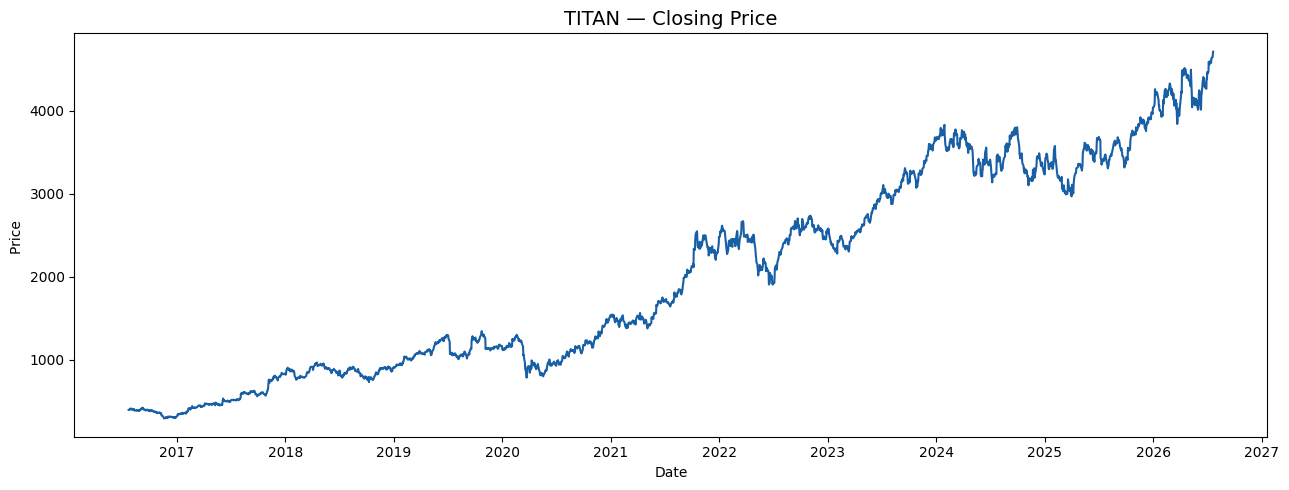

In [15]:
plt.figure(figsize=(13, 5))
plt.plot(df.index, df["Close"], linewidth=1.5, color="#185FA5")
plt.title("TITAN — Closing Price", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price ")
plt.tight_layout()
plt.show()


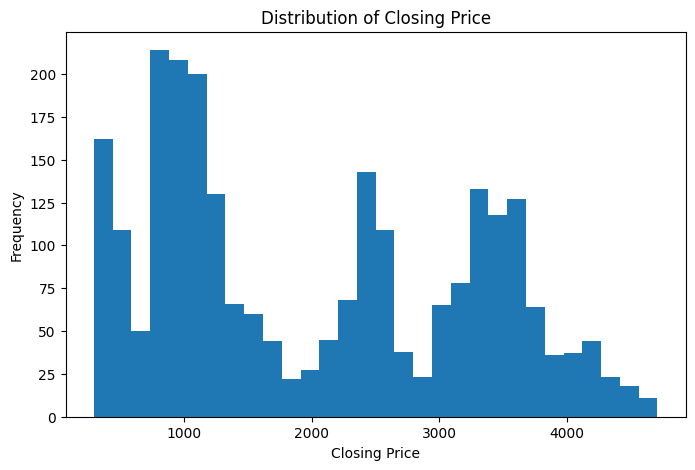

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df["Close"], bins=30)
plt.title("Distribution of Closing Price")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

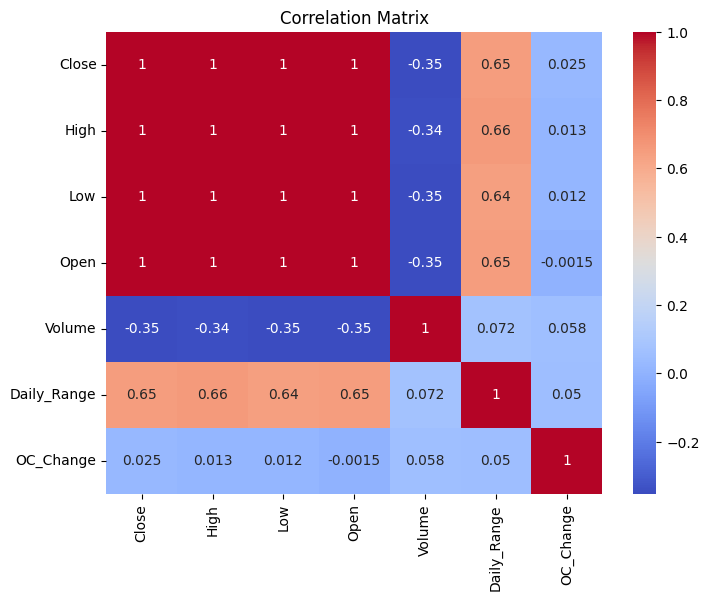

In [17]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

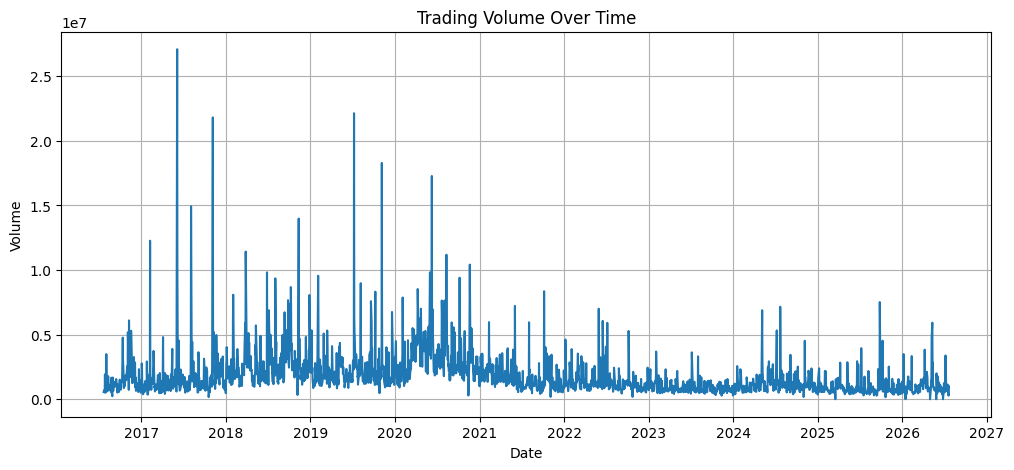

In [18]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["Volume"])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

In [19]:
import os

os.makedirs("plots", exist_ok=True)

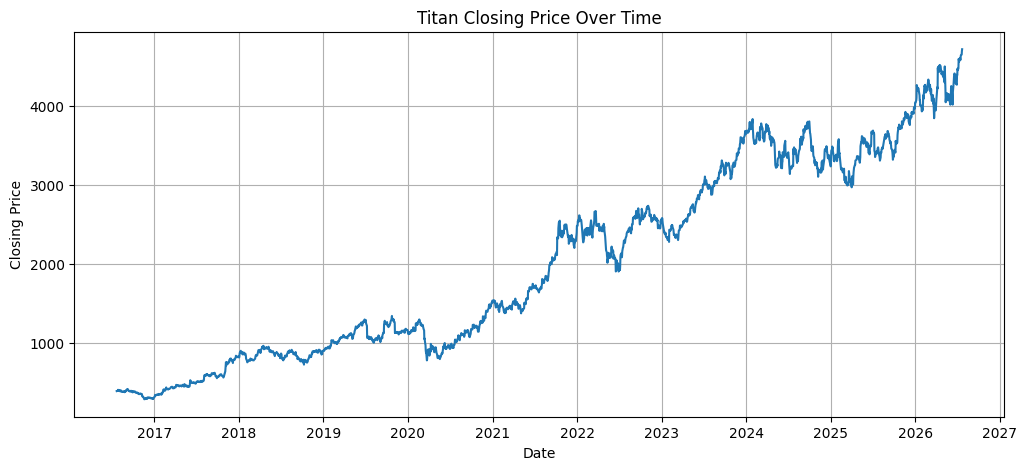

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index, df["Close"])
plt.title("Titan Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.savefig("plots/closing_price_trend.png", dpi=300, bbox_inches="tight")
plt.show()

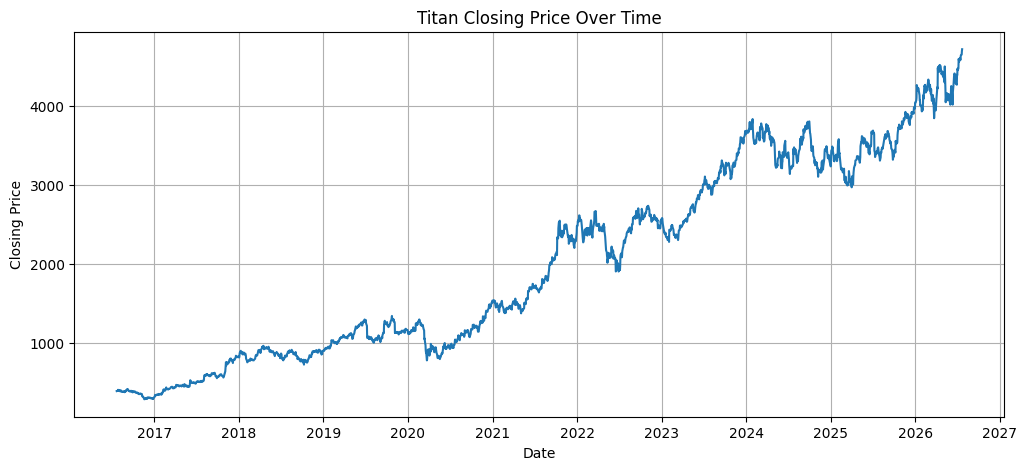

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index, df["Close"])
plt.title("Titan Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.savefig("plots/closing_price_trend.png", dpi=300, bbox_inches="tight")
plt.show()

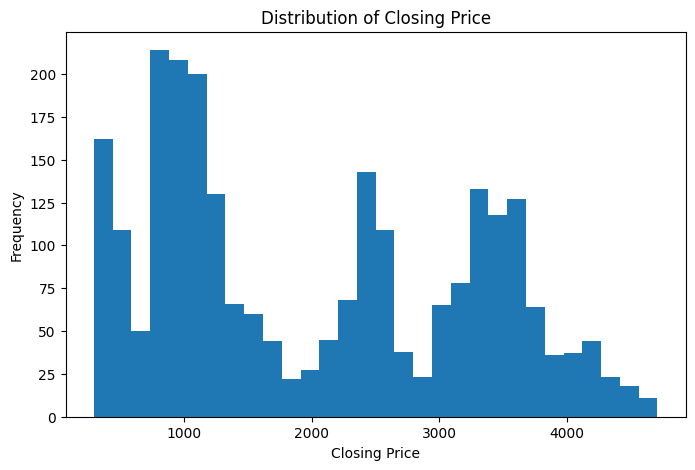

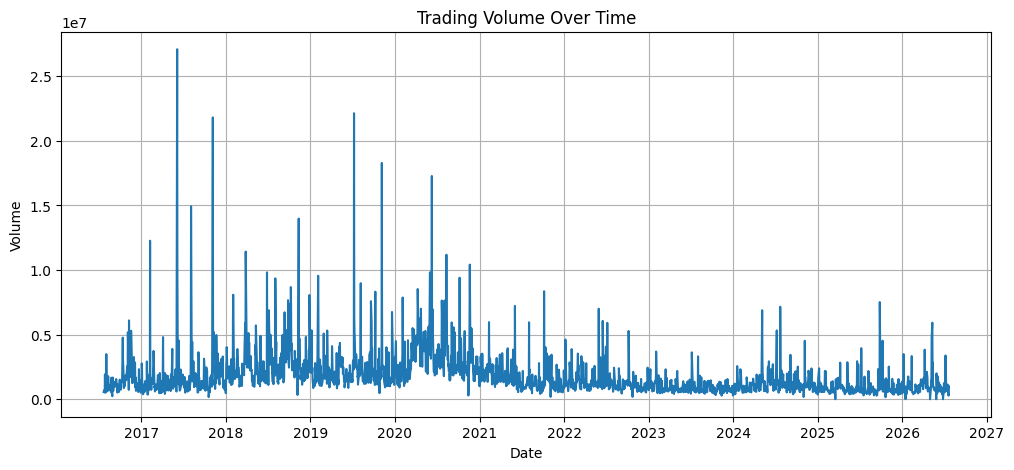

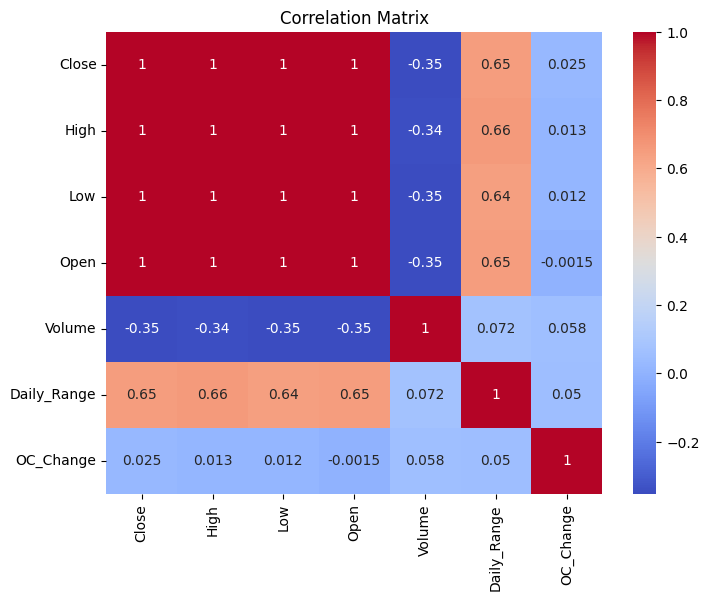

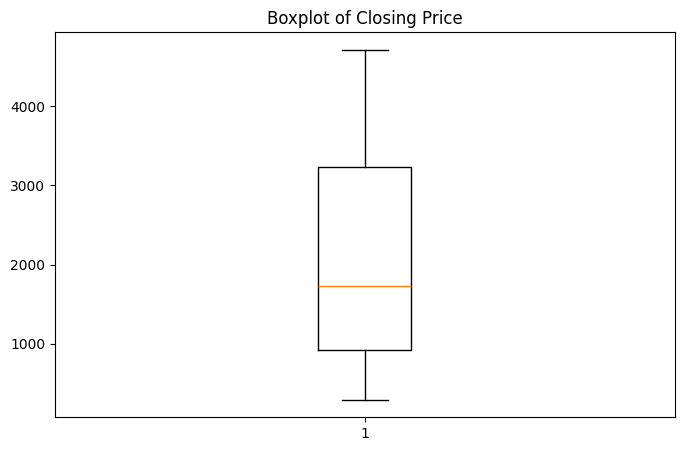

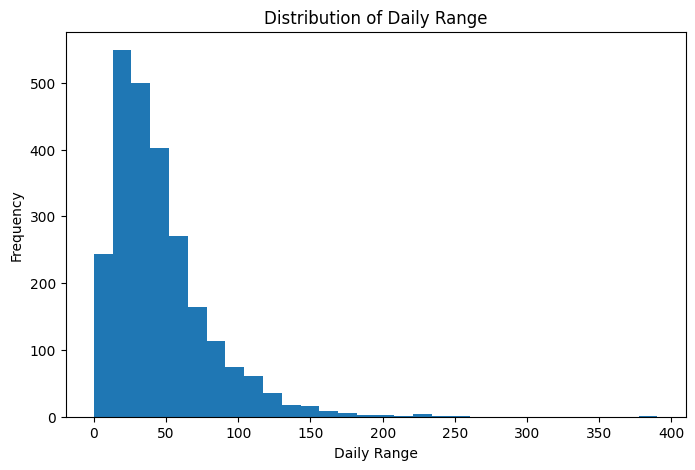

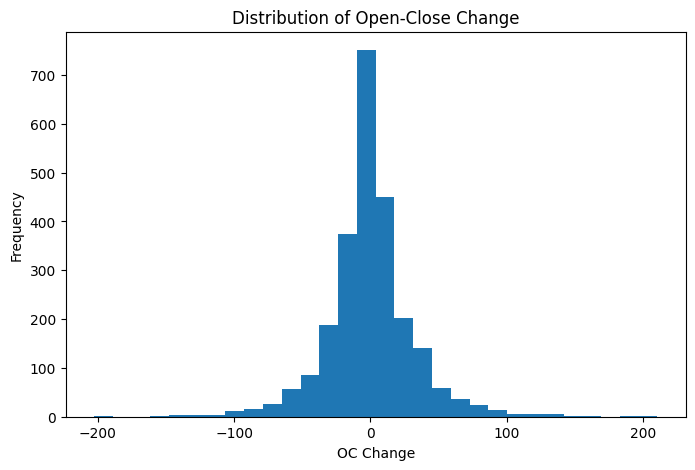

In [22]:
plt.figure(figsize=(8,5))
plt.hist(df["Close"], bins=30)
plt.title("Distribution of Closing Price")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.savefig("plots/closing_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df.index, df["Volume"])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)

plt.savefig("plots/trading_volume.png", dpi=300, bbox_inches="tight")
plt.show()

import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

plt.savefig("plots/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["Close"])
plt.title("Boxplot of Closing Price")

plt.savefig("plots/closing_price_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["Daily_Range"], bins=30)
plt.title("Distribution of Daily Range")
plt.xlabel("Daily Range")
plt.ylabel("Frequency")

plt.savefig("plots/daily_range_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["OC_Change"], bins=30)
plt.title("Distribution of Open-Close Change")
plt.xlabel("OC Change")
plt.ylabel("Frequency")

plt.savefig("plots/oc_change_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
df.columns


Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Range', 'OC_Change'], dtype='object')

In [24]:
df["Daily_Return"] = df["Close"].pct_change() * 100

In [25]:
df

,Close,High,Low,Open,Volume,Daily_Range,OC_Change,Daily_Return
Date,,,,,,,,
2016-07-22,395.115662,397.478430,391.258052,395.404971,562267,6.220378,-0.289309,NaN
2016-07-25,398.057098,401.673607,394.440589,396.369394,704244,7.233018,1.687704,0.744450
2016-07-26,399.262604,404.422163,396.562289,399.744805,675183,7.859874,-0.482201,0.302847
2016-07-27,397.044434,401.577107,392.704623,399.551856,529343,8.872483,-2.507422,-0.555567
2016-07-28,411.414062,417.104031,395.935387,397.044473,1930303,21.168644,14.369590,3.619149
...,...,...,...,...,...,...,...,...
2026-07-16,4625.799805,4668.799805,4580.000000,4585.299805,1136159,88.799805,40.500000,1.013231
2026-07-17,4638.100098,4647.500000,4610.100098,4626.000000,667212,37.399902,12.100098,0.265906
2026-07-20,4643.399902,4660.000000,4625.299805,4638.100098,274158,34.700195,5.299805,0.114267


In [26]:
df

,Close,High,Low,Open,Volume,Daily_Range,OC_Change,Daily_Return
Date,,,,,,,,
2016-07-22,395.115662,397.478430,391.258052,395.404971,562267,6.220378,-0.289309,NaN
2016-07-25,398.057098,401.673607,394.440589,396.369394,704244,7.233018,1.687704,0.744450
2016-07-26,399.262604,404.422163,396.562289,399.744805,675183,7.859874,-0.482201,0.302847
2016-07-27,397.044434,401.577107,392.704623,399.551856,529343,8.872483,-2.507422,-0.555567
2016-07-28,411.414062,417.104031,395.935387,397.044473,1930303,21.168644,14.369590,3.619149
...,...,...,...,...,...,...,...,...
2026-07-16,4625.799805,4668.799805,4580.000000,4585.299805,1136159,88.799805,40.500000,1.013231
2026-07-17,4638.100098,4647.500000,4610.100098,4626.000000,667212,37.399902,12.100098,0.265906
2026-07-20,4643.399902,4660.000000,4625.299805,4638.100098,274158,34.700195,5.299805,0.114267


In [27]:
import numpy as np

# Price change
delta = df["Close"].diff()

# Separate gains and losses
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

# Average gain and average loss (Wilder's EMA)
avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()

# Relative Strength (RS)
rs = avg_gain / avg_loss

# RSI
df["RSI_14"] = 100 - (100 / (1 + rs))

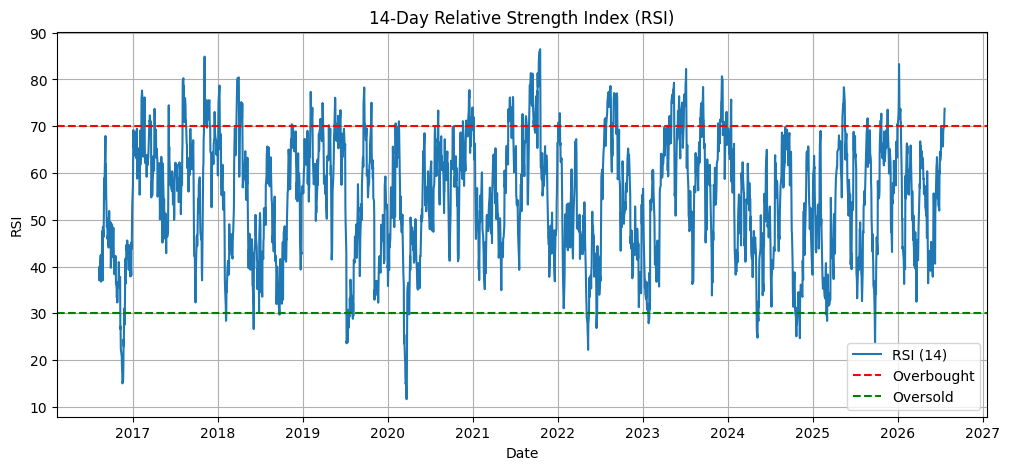

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index, df["RSI_14"], label="RSI (14)")
plt.axhline(70, color="red", linestyle="--", label="Overbought")
plt.axhline(30, color="green", linestyle="--", label="Oversold")

plt.title("14-Day Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.grid(True)

plt.savefig("plots/rsi_14.png", dpi=300, bbox_inches="tight")
plt.show()

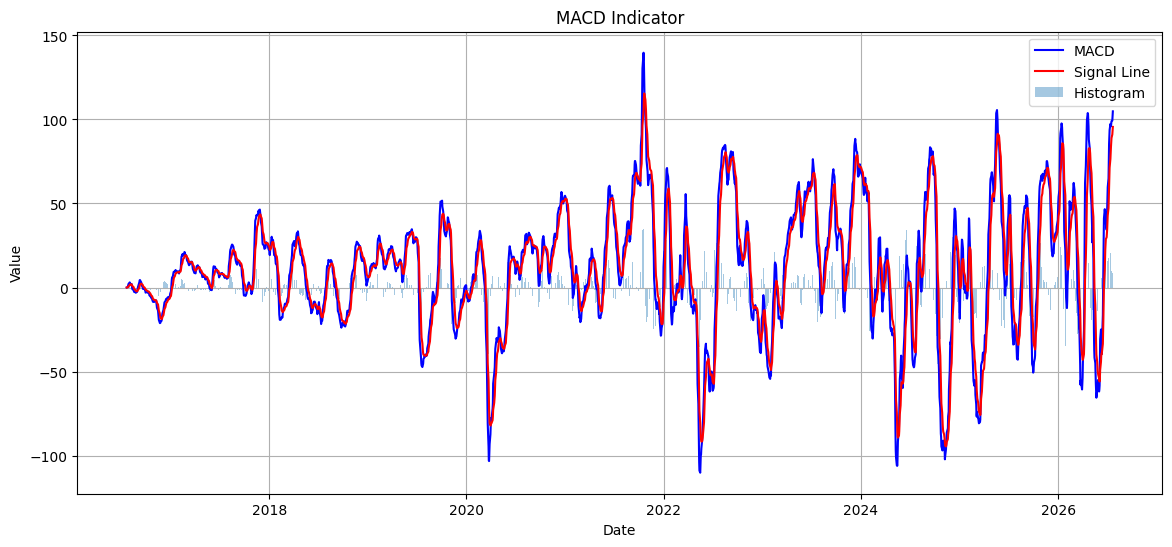

In [29]:
# 12-day and 26-day Exponential Moving Averages
ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

# MACD Line
df["MACD"] = ema_12 - ema_26

# Signal Line (9-day EMA of MACD)
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

df["MACD_Histogram"] = df["MACD"] - df["MACD_Signal"]

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(df.index, df["MACD"], label="MACD", color="blue")
plt.plot(df.index, df["MACD_Signal"], label="Signal Line", color="red")
plt.bar(df.index, df["MACD_Histogram"], label="Histogram", alpha=0.4)

plt.title("MACD Indicator")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.savefig("plots/macd.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
df["ROC_5"] = df["Close"].pct_change(periods=5) * 100
df["ROC_21"] = df["Close"].pct_change(periods=21) * 100

In [31]:
df[["Close", "ROC_5", "ROC_21"]].tail(10)

,Close,ROC_5,ROC_21
Date,,,
2026-07-09,4555.799805,2.000595,13.078564
2026-07-10,4584.399902,3.101087,14.266195
2026-07-13,4601.500000,2.947975,10.339363
2026-07-14,4573.700195,-0.336488,7.125193
2026-07-15,4579.399902,0.175001,5.911158
2026-07-16,4625.799805,1.536503,5.946316
2026-07-17,4638.100098,1.171368,6.048893
2026-07-20,4643.399902,0.910571,5.401398
2026-07-21,4688.700195,2.514376,7.583430


In [32]:
# Calculate Simple Moving Averages
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()

# Distance from Moving Averages (%)
df["Dist_SMA_20"] = ((df["Close"] - df["SMA_20"]) / df["SMA_20"]) * 100
df["Dist_SMA_50"] = ((df["Close"] - df["SMA_50"]) / df["SMA_50"]) * 100
df["Dist_SMA_200"] = ((df["Close"] - df["SMA_200"]) / df["SMA_200"]) * 100# Calculate Simple Moving Averages
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()

# Distance from Moving Averages (%)
df["Dist_SMA_20"] = ((df["Close"] - df["SMA_20"]) / df["SMA_20"]) * 100
df["Dist_SMA_50"] = ((df["Close"] - df["SMA_50"]) / df["SMA_50"]) * 100
df["Dist_SMA_200"] = ((df["Close"] - df["SMA_200"]) / df["SMA_200"]) * 100

df[[
    "Close",
    "SMA_20", "Dist_SMA_20",
    "SMA_50", "Dist_SMA_50",
    "SMA_200", "Dist_SMA_200"
]].tail(10)

,Close,SMA_20,Dist_SMA_20,SMA_50,Dist_SMA_50,SMA_200,Dist_SMA_200
Date,,,,,,,
2026-07-09,4555.799805,4377.922168,4.063061,4246.140142,7.292733,4045.020331,12.627365
2026-07-10,4584.399902,4398.626367,4.223444,4250.410981,7.857803,4050.663029,13.176531
2026-07-13,4601.500000,4415.226831,4.218881,4255.466372,8.131509,4056.439569,13.436917
2026-07-14,4573.700195,4427.721216,3.296932,4259.754458,7.370043,4062.168311,12.592582
2026-07-15,4579.399902,4438.382544,3.177224,4264.435620,7.385837,4068.029708,12.570464
2026-07-16,4625.799805,4450.995093,3.927318,4271.083374,8.305069,4074.321455,13.535465
2026-07-17,4638.100098,4462.627881,3.932038,4273.960317,8.519962,4080.929866,13.653021
2026-07-20,4643.399902,4476.887915,3.719369,4282.991411,8.414878,4087.196484,13.608434
2026-07-21,4688.700195,4496.761963,4.268365,4295.924678,9.142980,4093.860045,14.530056


In [33]:
# 20-day Bollinger Bands
df["BB_Middle"] = df["Close"].rolling(window=20).mean()
rolling_std = df["Close"].rolling(window=20).std()

df["BB_Upper"] = df["BB_Middle"] + (2 * rolling_std)
df["BB_Lower"] = df["BB_Middle"] - (2 * rolling_std)

# Bollinger Band Width
df["BB_Width"] = (
    (df["BB_Upper"] - df["BB_Lower"])
    / df["BB_Middle"]
) * 100

In [34]:
df[[
    "Close",
    "BB_Upper",
    "BB_Middle",
    "BB_Lower",
    "BB_Width"
]].tail(10)

,Close,BB_Upper,BB_Middle,BB_Lower,BB_Width
Date,,,,,
2026-07-09,4555.799805,4602.479039,4377.922168,4153.365297,10.258605
2026-07-10,4584.399902,4618.904620,4398.626367,4178.348114,10.015775
2026-07-13,4601.500000,4644.391035,4415.226831,4186.062627,10.380631
2026-07-14,4573.700195,4663.065147,4427.721216,4192.377284,10.630476
2026-07-15,4579.399902,4681.187271,4438.382544,4195.577817,10.941136
2026-07-16,4625.799805,4705.542135,4450.995093,4196.448050,11.437759
2026-07-17,4638.100098,4729.382020,4462.627881,4195.873742,11.955025
2026-07-20,4643.399902,4750.539871,4476.887915,4203.235959,12.225098
2026-07-21,4688.700195,4771.370832,4496.761963,4222.153094,12.213627


In [35]:
# True Range (TR)
high_low = df["High"] - df["Low"]
high_prev_close = (df["High"] - df["Close"].shift(1)).abs()
low_prev_close = (df["Low"] - df["Close"].shift(1)).abs()

df["TR"] = pd.concat(
    [high_low, high_prev_close, low_prev_close],
    axis=1
).max(axis=1)

# 14-day Average True Range (ATR)
df["ATR_14"] = df["TR"].ewm(alpha=1/14, adjust=False, min_periods=14).mean()

In [36]:
# 10-day Moving Average of Volume
df["Volume_MA_10"] = df["Volume"].rolling(window=10).mean()

# Volume Change Ratio
df["Volume_Change_Ratio"] = df["Volume"] / df["Volume_MA_10"]

In [37]:
# Money Flow Multiplier
mfm = (
    ((df["Close"] - df["Low"]) - (df["High"] - df["Close"]))
    / (df["High"] - df["Low"])
).fillna(0)

# Money Flow Volume
mfv = mfm * df["Volume"]

# 20-day Chaikin Money Flow (CMF)
df["CMF_20"] = (
    mfv.rolling(window=20).sum()
    / df["Volume"].rolling(window=20).sum()
)

In [38]:
# On-Balance Volume (OBV)
df["OBV"] = (
    np.sign(df["Close"].diff()).fillna(0) * df["Volume"]
).cumsum()

# 10-day OBV Slope
df["OBV_Slope_10"] = df["OBV"].diff(10) / 10

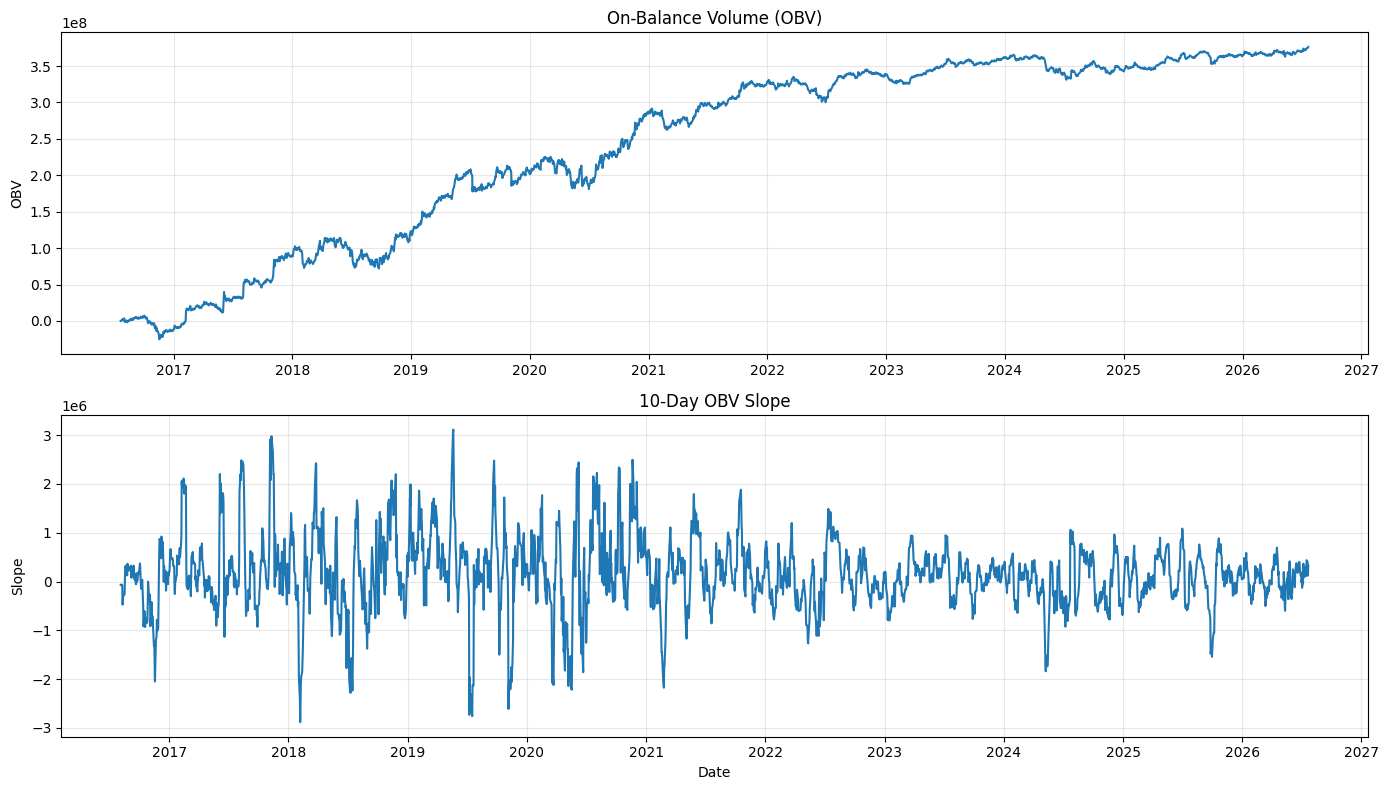

In [39]:
plt.figure(figsize=(14, 8))

# OBV
plt.subplot(2, 1, 1)
plt.plot(df.index, df["OBV"])
plt.title("On-Balance Volume (OBV)")
plt.ylabel("OBV")
plt.grid(alpha=0.3)

# OBV Slope
plt.subplot(2, 1, 2)
plt.plot(df.index, df["OBV_Slope_10"])
plt.title("10-Day OBV Slope")
plt.xlabel("Date")
plt.ylabel("Slope")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("plots/obv_and_obv_slope.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
df["Return_Lag_1"] = df["Daily_Return"].shift(1)
df["Return_Lag_2"] = df["Daily_Return"].shift(2)
df["Return_Lag_3"] = df["Daily_Return"].shift(3)
df["Return_Lag_5"] = df["Daily_Return"].shift(5)

In [41]:
df["Kyle_Lambda_Proxy"] = (
    df["Daily_Return"].abs() / df["Volume"]
)

df["Kyle_Lambda_20"] = (
    df["Kyle_Lambda_Proxy"]
    .rolling(window=20)
    .mean()
)

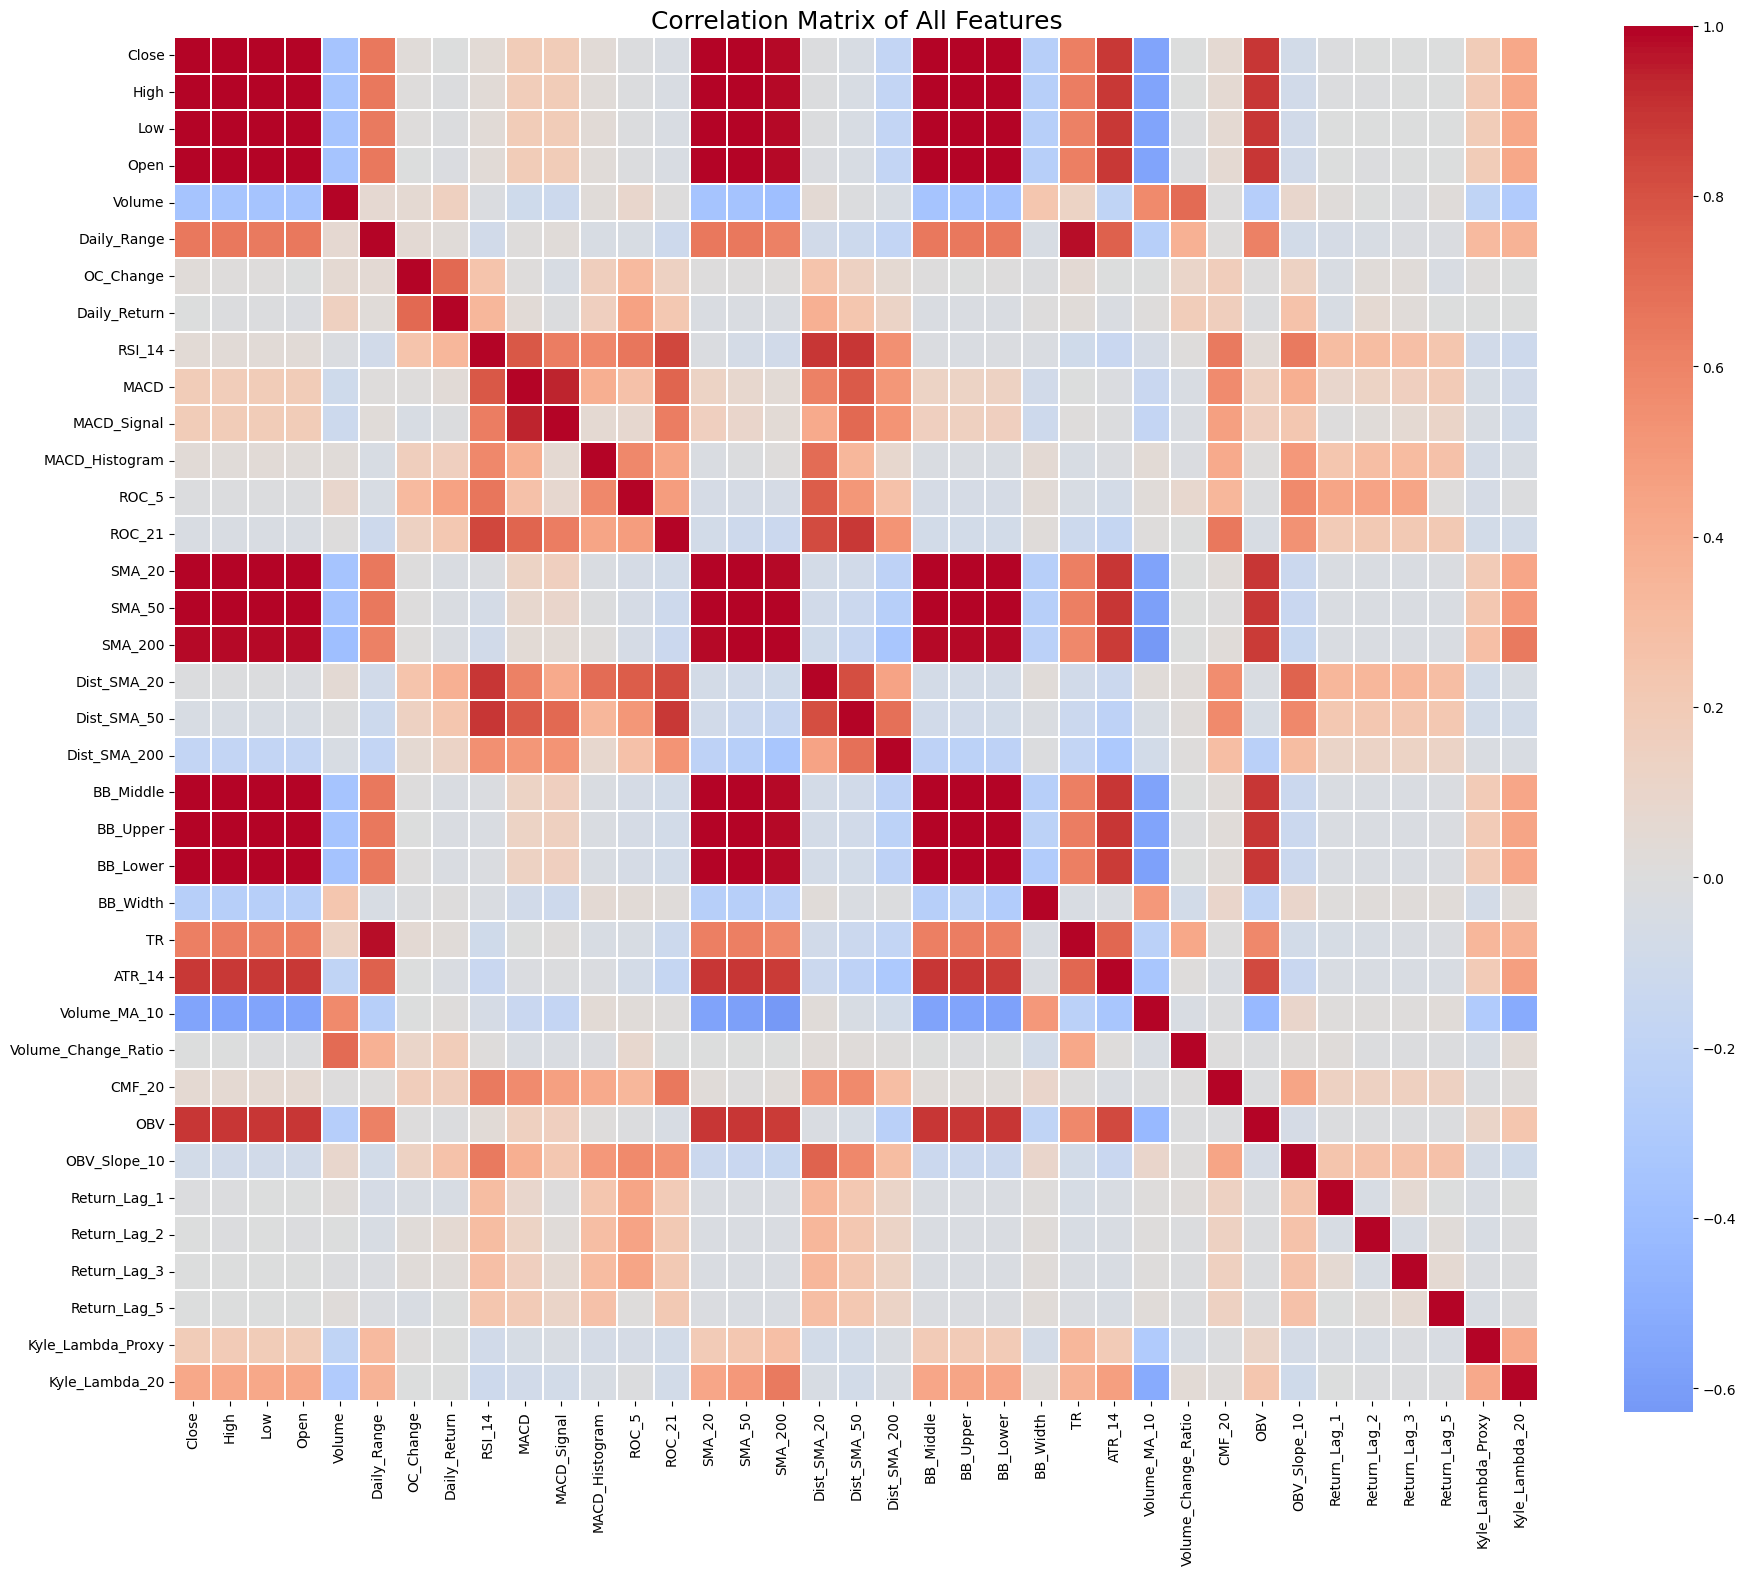

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22, 18))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    square=True
)

plt.title("Correlation Matrix of All Features", fontsize=18)

plt.savefig(
    "plots/feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# Remove last row (no next day's label)
df.dropna(inplace=True)

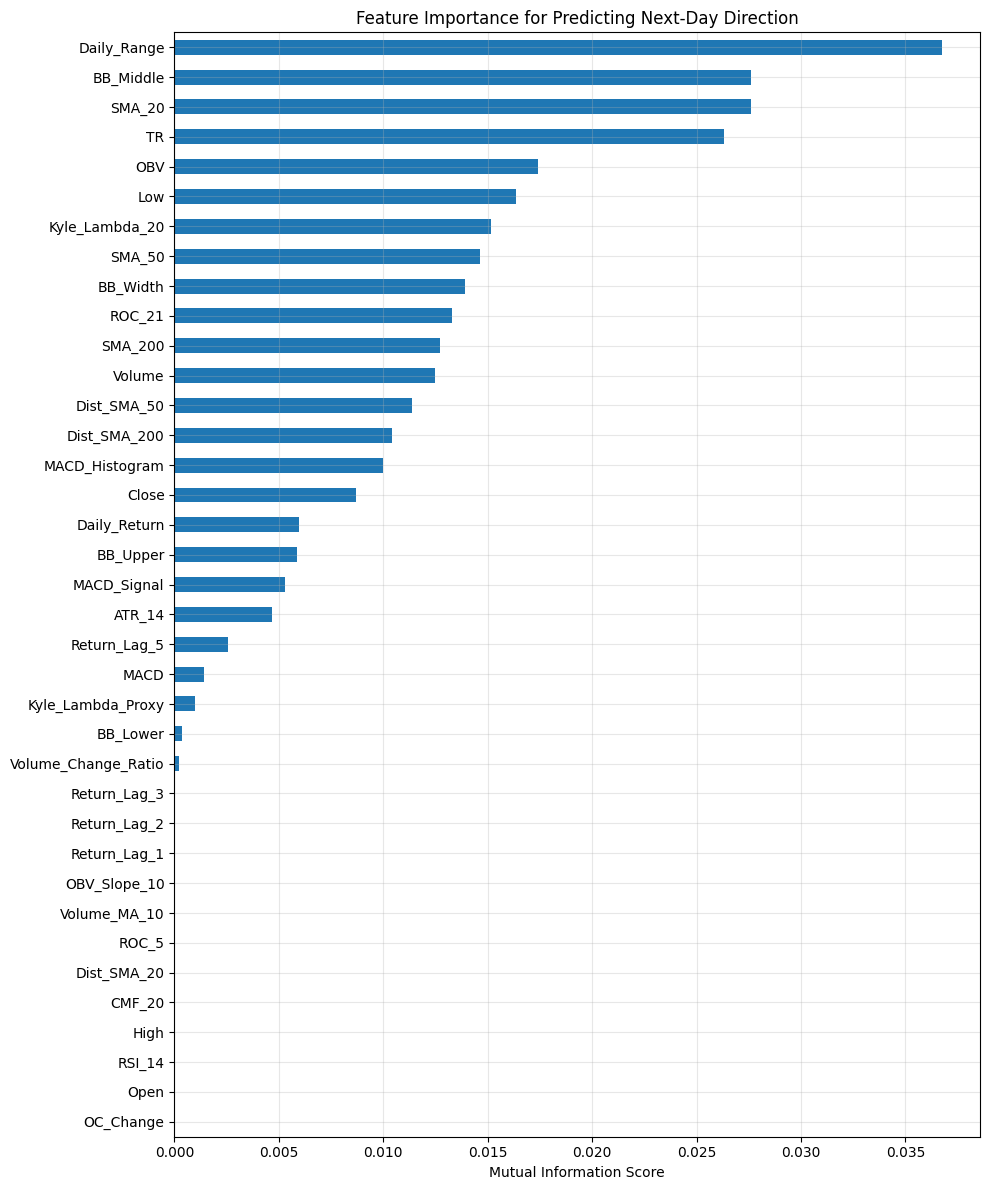

In [44]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns=["Target"])
X = X.select_dtypes(include="number")

y = df["Target"]

mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

importance = (
    pd.Series(mi, index=X.columns)
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 12))

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance for Predicting Next-Day Direction")
plt.xlabel("Mutual Information Score")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "plots/feature_importance_mutual_information.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

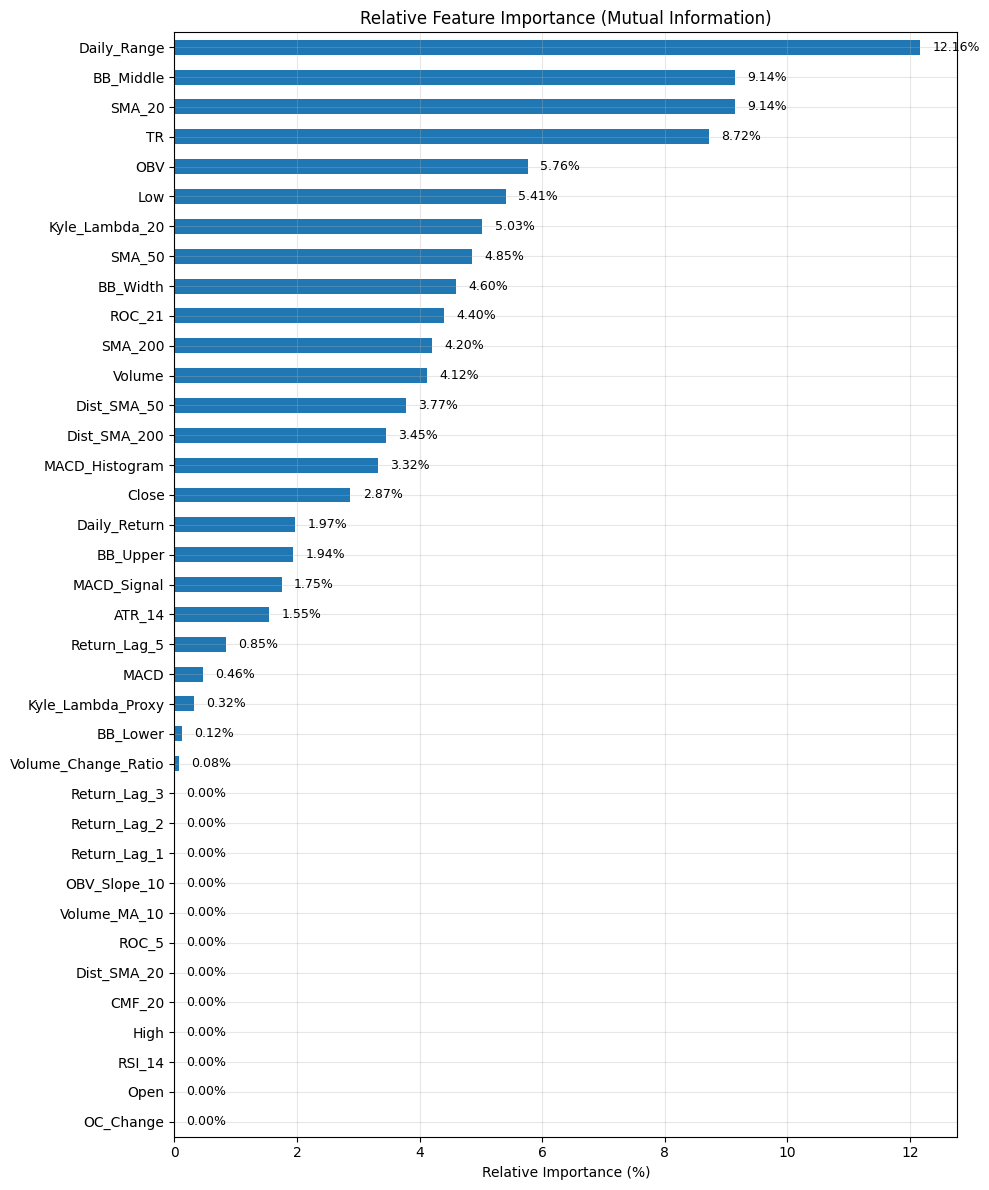

In [45]:
# Convert MI scores to relative percentages
importance_pct = (importance / importance.sum()) * 100

plt.figure(figsize=(10, 12))

ax = importance_pct.sort_values().plot(kind="barh")

plt.title("Relative Feature Importance (Mutual Information)")
plt.xlabel("Relative Importance (%)")

# Write percentage on each bar
for i, value in enumerate(importance_pct.sort_values()):
    ax.text(
        value + 0.2,
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=9
    )

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "plots/feature_importance_mutual_information.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
importance_df = pd.DataFrame({
    "Mutual Information": importance,
    "Relative Importance (%)": (importance / importance.sum() * 100)
})

importance_df = importance_df.sort_values(
    by="Relative Importance (%)",
    ascending=False
)

importance_df["Relative Importance (%)"] = (
    importance_df["Relative Importance (%)"].round(2)
)

importance_df

,Mutual Information,Relative Importance (%)
Daily_Range,0.036734,12.16
SMA_20,0.027602,9.14
BB_Middle,0.027602,9.14
TR,0.026332,8.72
OBV,0.017405,5.76
Low,0.016348,5.41
Kyle_Lambda_20,0.015181,5.03
SMA_50,0.014653,4.85
BB_Width,0.013892,4.60
ROC_21,0.013282,4.40


In [47]:
# Remove redundant / duplicate features
features_to_drop = [
    "BB_Middle",   # Duplicate of SMA_20
    "SMA_50",      # Dist_SMA_50 contains the same information in normalized form
    "SMA_200"      # Dist_SMA_200 contains the same information in normalized form
]

df.drop(columns=features_to_drop, inplace=True)

print("Dropped Features:")
for feature in features_to_drop:
    print(f"- {feature}")

print(f"\nRemaining columns: {len(df.columns)}")

Dropped Features:
- BB_Middle
- SMA_50
- SMA_200

Remaining columns: 35


In [48]:
df.columns


Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Range', 'OC_Change',
       'Daily_Return', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Histogram',
       'ROC_5', 'ROC_21', 'SMA_20', 'Dist_SMA_20', 'Dist_SMA_50',
       'Dist_SMA_200', 'BB_Upper', 'BB_Lower', 'BB_Width', 'TR', 'ATR_14',
       'Volume_MA_10', 'Volume_Change_Ratio', 'CMF_20', 'OBV', 'OBV_Slope_10',
       'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5',
       'Kyle_Lambda_Proxy', 'Kyle_Lambda_20', 'Target'],
      dtype='object')

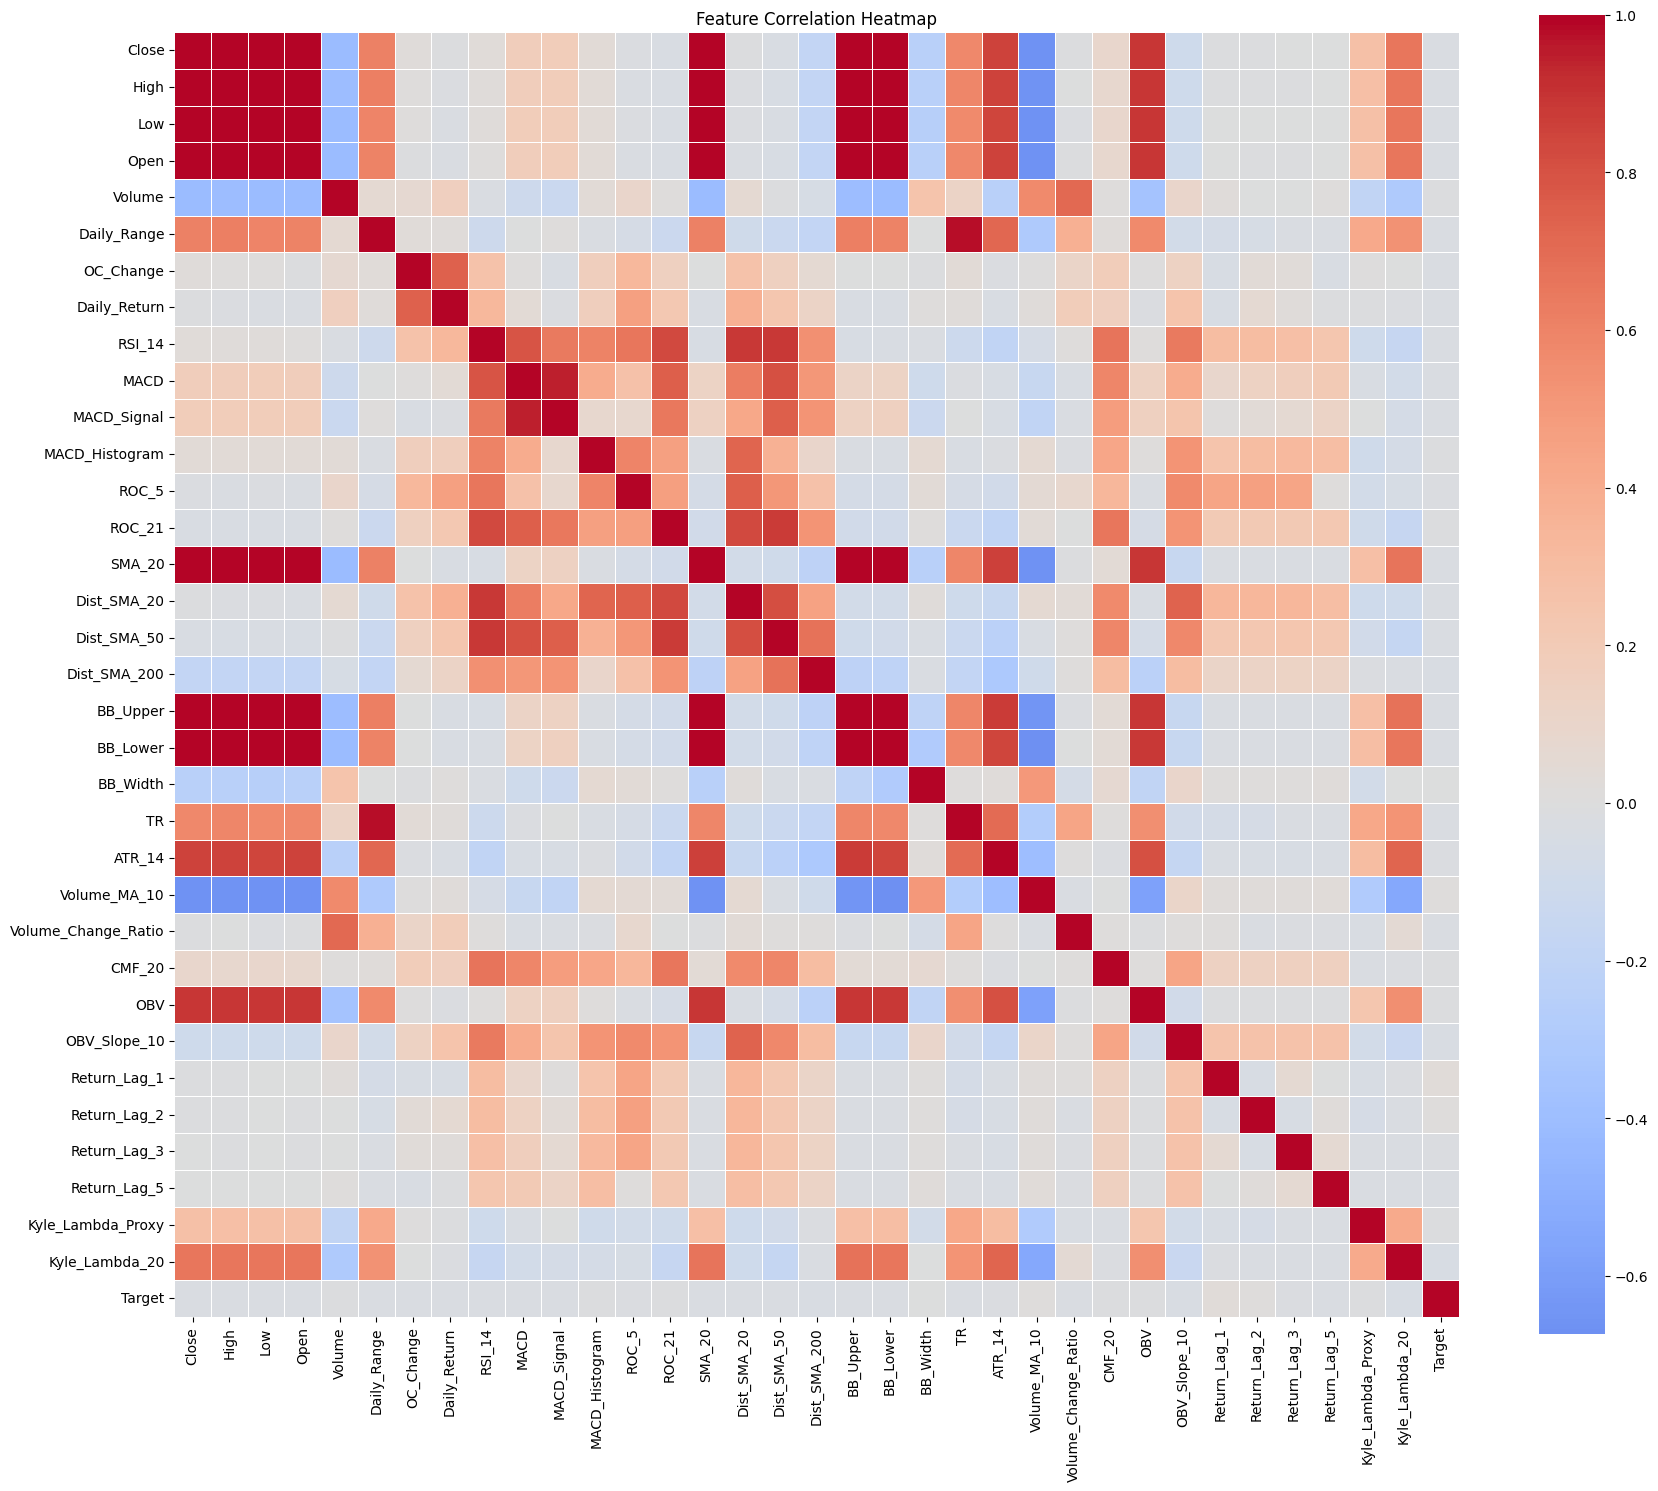


Feature pairs with |correlation| > 0.9

Close                <--> High                 : 0.9998
Close                <--> Low                  : 0.9998
High                 <--> Open                 : 0.9998
Low                  <--> Open                 : 0.9998
High                 <--> Low                  : 0.9998
Close                <--> Open                 : 0.9996
SMA_20               <--> BB_Upper             : 0.9989
SMA_20               <--> BB_Lower             : 0.9987
Open                 <--> SMA_20               : 0.9972
High                 <--> SMA_20               : 0.9971
Low                  <--> SMA_20               : 0.9969
Close                <--> SMA_20               : 0.9969
Open                 <--> BB_Upper             : 0.9962
High                 <--> BB_Upper             : 0.9962
Close                <--> BB_Upper             : 0.9958
Open                 <--> BB_Lower             : 0.9957
Low                  <--> BB_Upper             : 0.9957
High   

In [49]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
corr = df.select_dtypes(include="number").corr()

# Plot heatmap
plt.figure(figsize=(18, 15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "plots/feature_correlation_heatmap_after_reduction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -------------------------
# Find highly correlated pairs
# -------------------------

threshold = 0.90

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = []

for col in upper.columns:
    for row in upper.index:
        value = upper.loc[row, col]
        if pd.notna(value) and abs(value) > threshold:
            high_corr.append((row, col, value))

print(f"\nFeature pairs with |correlation| > {threshold}\n")

for f1, f2, corr_value in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"{f1:20s} <--> {f2:20s} : {corr_value:.4f}")

In [50]:
# Features to remove and reasons:
# High        -> Same information as Close
# Low         -> Same information as Close
# Open        -> Same information as Close
# SMA_20      -> Dist_SMA_20 is a normalized and more informative version
# BB_Upper    -> Highly correlated with SMA_20
# BB_Lower    -> Highly correlated with SMA_20
# Daily_Range -> True Range (TR) already captures this information
# MACD        -> MACD_Histogram = MACD - MACD_Signal, so histogram captures the signal difference
# MACD_Signal -> Redundant when using MACD_Histogram

features_to_drop = [
    "High",
    "Low",
    "Open",
    "SMA_20",
    "BB_Upper",
    "BB_Lower",
    "Daily_Range",
    "MACD",
    "MACD_Signal"
]

df.drop(columns=features_to_drop, inplace=True)

print("Dropped Features:")
for feature in features_to_drop:
    print(f"- {feature}")

print(f"\nRemaining features: {len(df.columns)}")
print(df.columns.tolist())

Dropped Features:
- High
- Low
- Open
- SMA_20
- BB_Upper
- BB_Lower
- Daily_Range
- MACD
- MACD_Signal

Remaining features: 26
['Close', 'Volume', 'OC_Change', 'Daily_Return', 'RSI_14', 'MACD_Histogram', 'ROC_5', 'ROC_21', 'Dist_SMA_20', 'Dist_SMA_50', 'Dist_SMA_200', 'BB_Width', 'TR', 'ATR_14', 'Volume_MA_10', 'Volume_Change_Ratio', 'CMF_20', 'OBV', 'OBV_Slope_10', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Kyle_Lambda_Proxy', 'Kyle_Lambda_20', 'Target']


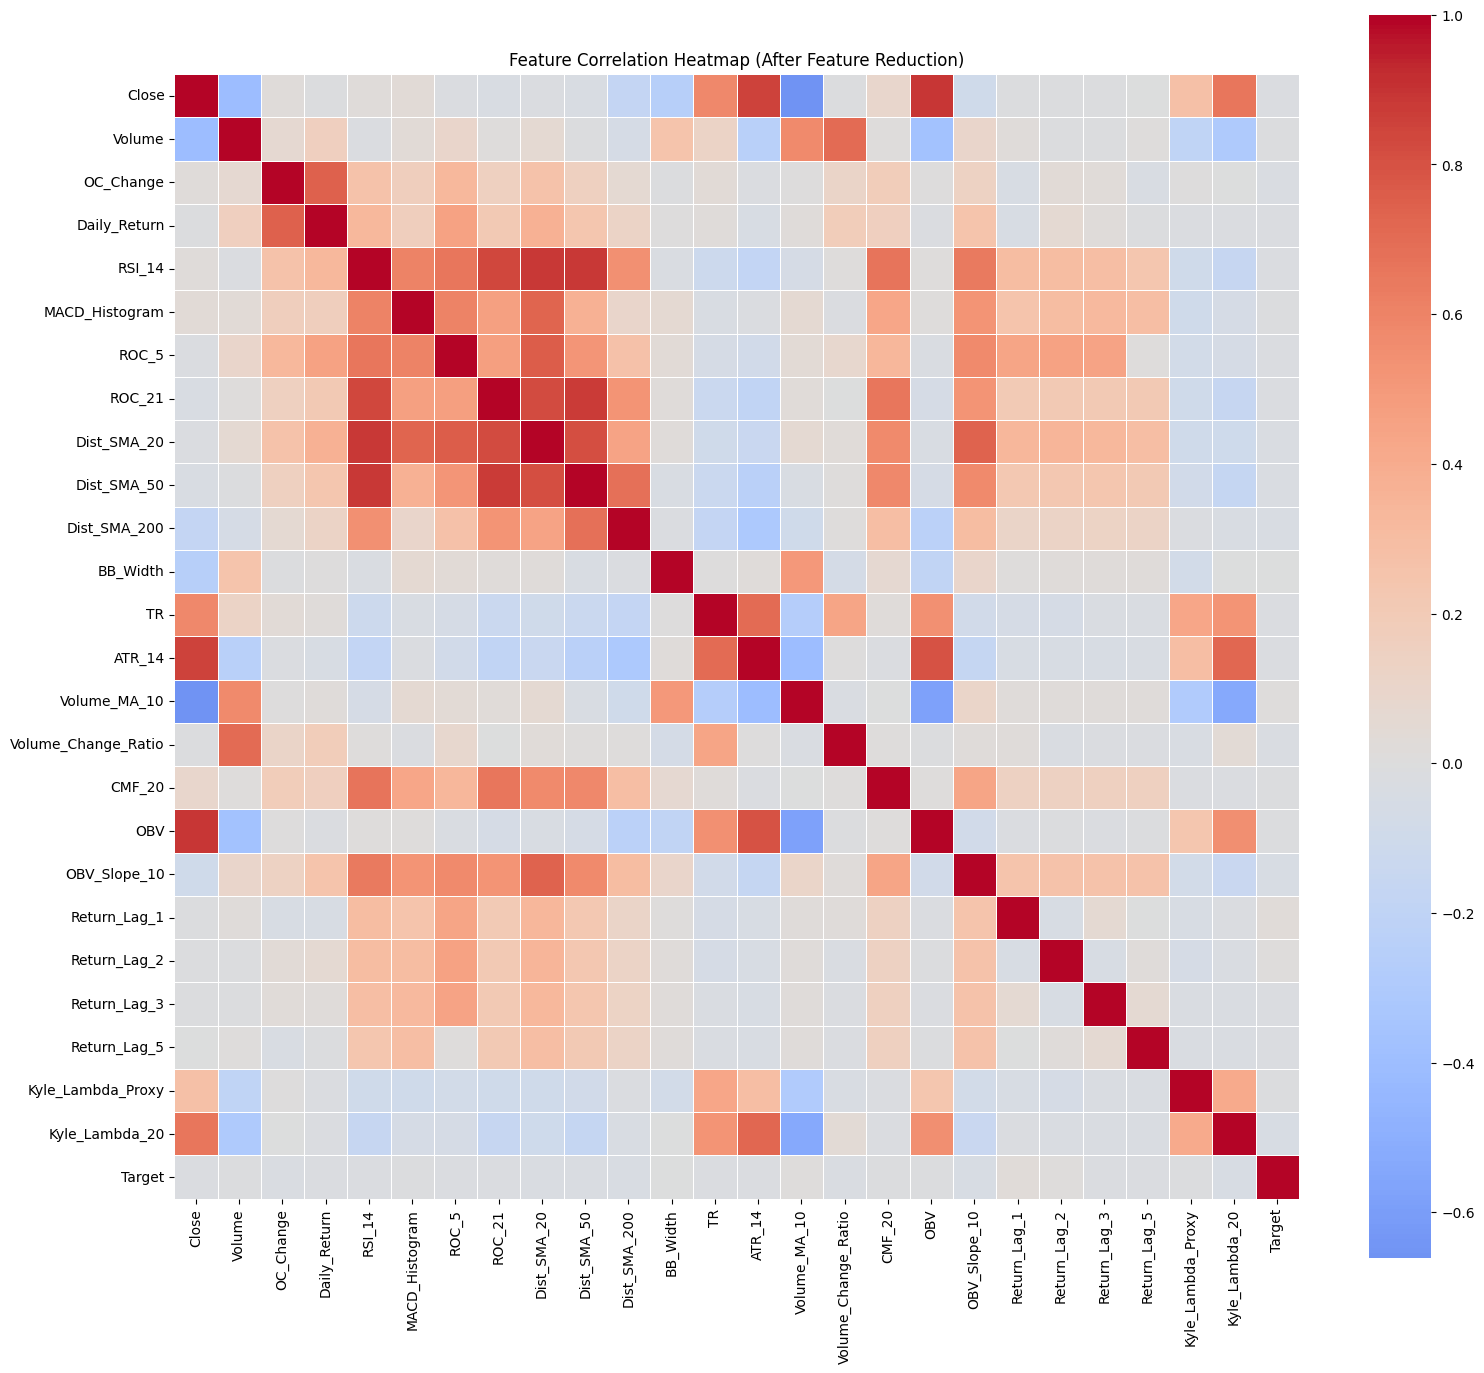

Feature pairs with |correlation| > 0.8:

  Feature 1   Feature 2  Correlation
      Close         OBV     0.892725
     RSI_14 Dist_SMA_20     0.887155
     RSI_14 Dist_SMA_50     0.887079
     ROC_21 Dist_SMA_50     0.880169
      Close      ATR_14     0.850790
     RSI_14      ROC_21     0.836174
     ROC_21 Dist_SMA_20     0.823794
Dist_SMA_20 Dist_SMA_50     0.812115
     ATR_14         OBV     0.803976


In [51]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df.select_dtypes(include="number").corr()

# Heatmap
plt.figure(figsize=(16, 14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap (After Feature Reduction)")

plt.tight_layout()

plt.savefig(
    "plots/feature_correlation_heatmap_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Print feature pairs with |correlation| > 0.90
# --------------------------------------------------

threshold = 0.80

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={
             "level_0": "Feature 1",
             "level_1": "Feature 2",
             0: "Correlation"
         })
)

high_corr = high_corr[high_corr["Correlation"].abs() > threshold]
high_corr = high_corr.reindex(
    high_corr["Correlation"].abs().sort_values(ascending=False).index
)

if high_corr.empty:
    print(f"No feature pairs with |correlation| > {threshold}.")
else:
    print(f"Feature pairs with |correlation| > {threshold}:\n")
    print(high_corr.to_string(index=False))

In [52]:
df.columns

Index(['Close', 'Volume', 'OC_Change', 'Daily_Return', 'RSI_14',
       'MACD_Histogram', 'ROC_5', 'ROC_21', 'Dist_SMA_20', 'Dist_SMA_50',
       'Dist_SMA_200', 'BB_Width', 'TR', 'ATR_14', 'Volume_MA_10',
       'Volume_Change_Ratio', 'CMF_20', 'OBV', 'OBV_Slope_10', 'Return_Lag_1',
       'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Kyle_Lambda_Proxy',
       'Kyle_Lambda_20', 'Target'],
      dtype='object')

In [53]:
df["ATR_Pct"] = df["ATR_14"] / df["Close"] * 100

In [54]:
correlation = df["ATR_14"].corr(df["ATR_Pct"])

print(f"Correlation between ATR_14 and ATR_Pct: {correlation:.4f}")

Correlation between ATR_14 and ATR_Pct: -0.0271


In [55]:
# Drop ATR_14 since ATR_Pct is its normalized replacement
df.drop(columns=["ATR_14"], inplace=True)

print("Dropped feature:")
print("- ATR_14 (replaced by ATR_Pct)")

print(f"\nRemaining features: {len(df.columns)}")

Dropped feature:
- ATR_14 (replaced by ATR_Pct)

Remaining features: 26


In [56]:
df.head(2)

,Close,Volume,OC_Change,Daily_Return,RSI_14,MACD_Histogram,ROC_5,ROC_21,Dist_SMA_20,Dist_SMA_50,...,OBV,OBV_Slope_10,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_5,Kyle_Lambda_Proxy,Kyle_Lambda_20,Target,ATR_Pct
Date,,,,,,,,,,,,,,,,,,,,,
2017-05-16,470.917664,1308863,2.218114,0.961438,54.414226,-0.542549,4.527457,0.857183,1.188965,4.006917,...,18731000.0,-459527.6,-2.292927,-1.227181,3.886817,-3.590963,7.345598e-07,0.000001,0,2.966793
2017-05-17,464.600830,859054,-7.956319,-1.341388,51.024710,-1.012836,-0.134743,0.103891,-0.277381,2.388026,...,17871946.0,-394353.8,0.961438,-2.292927,-1.227181,3.264480,1.561471e-06,0.000001,0,2.982120


In [57]:
rows_before = len(df)

df.dropna(inplace=True)

rows_after = len(df)

print(f"Rows before removing NaNs : {rows_before}")
print(f"Rows after removing NaNs  : {rows_after}")
print(f"Rows removed             : {rows_before - rows_after}")

Rows before removing NaNs : 2175
Rows after removing NaNs  : 2175
Rows removed             : 0


In [58]:
df

,Close,Volume,OC_Change,Daily_Return,RSI_14,MACD_Histogram,ROC_5,ROC_21,Dist_SMA_20,Dist_SMA_50,...,OBV,OBV_Slope_10,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_5,Kyle_Lambda_Proxy,Kyle_Lambda_20,Target,ATR_Pct
Date,,,,,,,,,,,,,,,,,,,,,
2017-05-16,470.917664,1308863,2.218114,0.961438,54.414226,-0.542549,4.527457,0.857183,1.188965,4.006917,...,18731000.0,-459527.6,-2.292927,-1.227181,3.886817,-3.590963,7.345598e-07,0.000001,0,2.966793
2017-05-17,464.600830,859054,-7.956319,-1.341388,51.024710,-1.012836,-0.134743,0.103891,-0.277381,2.388026,...,17871946.0,-394353.8,0.961438,-2.292927,-1.227181,3.264480,1.561471e-06,0.000001,0,2.982120
2017-05-18,454.860352,811219,-7.088363,-2.096526,46.241467,-1.929124,-5.886465,0.095510,-2.362029,0.106119,...,17060727.0,-582573.0,-1.341388,0.961438,-2.292927,3.886817,2.584415e-06,0.000001,0,3.018473
2017-05-19,454.378174,1022479,-3.712955,-0.106006,46.011524,-2.481683,-4.818178,-0.232923,-2.381160,-0.140309,...,16038248.0,-549977.7,-2.096526,-1.341388,0.961438,-1.227181,1.036751e-07,0.000001,1,3.096165
2017-05-22,464.263245,1725108,7.136571,2.175516,51.352341,-2.110028,-0.465223,0.396240,-0.278108,1.851469,...,17763356.0,-313907.0,-0.106006,-2.096526,-1.341388,-2.292927,1.261090e-06,0.000001,0,3.000749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-27,4427.272461,649222,2.990188,0.721084,57.279429,0.596276,-1.577668,15.278595,2.400707,4.596463,...,369385534.0,-162002.2,-1.043425,0.042647,-0.560298,-0.285028,1.110689e-06,0.000001,0,2.515216
2026-04-28,4402.553711,620778,4.684823,-0.558329,55.444132,-4.725597,-1.399651,13.270930,1.387561,3.940070,...,368764756.0,-139034.4,0.721084,-1.043425,0.042647,-0.737865,8.994022e-07,0.000001,1,2.477394
2026-04-29,4425.279297,702730,19.834819,0.516191,56.814138,-7.108167,-0.332249,9.915079,1.377679,4.382915,...,369467486.0,-160612.7,-0.558329,0.721084,-1.043425,-0.560298,7.345510e-07,0.000001,0,2.388692


In [59]:
df.to_csv("final_df_for_ml.csv", index=True)

print("Dataset saved as 'final_df_for_ml.csv'")

Dataset saved as 'final_df_for_ml.csv'


In [60]:
df = pd.read_csv("final_df_for_ml.csv", index_col=0, parse_dates=True)

In [61]:
print(X.dtypes)

Close                  float64
High                   float64
Low                    float64
Open                   float64
Volume                   int64
Daily_Range            float64
OC_Change              float64
Daily_Return           float64
RSI_14                 float64
MACD                   float64
MACD_Signal            float64
MACD_Histogram         float64
ROC_5                  float64
ROC_21                 float64
SMA_20                 float64
SMA_50                 float64
SMA_200                float64
Dist_SMA_20            float64
Dist_SMA_50            float64
Dist_SMA_200           float64
BB_Middle              float64
BB_Upper               float64
BB_Lower               float64
BB_Width               float64
TR                     float64
ATR_14                 float64
Volume_MA_10           float64
Volume_Change_Ratio    float64
CMF_20                 float64
OBV                    float64
OBV_Slope_10           float64
Return_Lag_1           float64
Return_L

In [62]:
print(X.isna().sum()[X.isna().sum() > 0])

Series([], dtype: int64)


In [63]:
print(X.shape)
print(X.isna().any(axis=1).sum())

(2175, 37)
0


In [64]:
rows_with_3_nans = df[df.isna().sum(axis=1) == 3]

print(rows_with_3_nans)

Empty DataFrame
Columns: [Close, Volume, OC_Change, Daily_Return, RSI_14, MACD_Histogram, ROC_5, ROC_21, Dist_SMA_20, Dist_SMA_50, Dist_SMA_200, BB_Width, TR, Volume_MA_10, Volume_Change_Ratio, CMF_20, OBV, OBV_Slope_10, Return_Lag_1, Return_Lag_2, Return_Lag_3, Return_Lag_5, Kyle_Lambda_Proxy, Kyle_Lambda_20, Target, ATR_Pct]
Index: []

[0 rows x 26 columns]


In [65]:
print(X.isna().sum().sum())

0


In [66]:
import numpy as np
import pandas as pd

# -----------------------------
# Prepare X and y
# -----------------------------
X = df.drop(columns=["Target"])
y = df["Target"]

print("=" * 70)
print("ML READINESS CHECK")
print("=" * 70)

# -----------------------------
# Shape
# -----------------------------
print("\n1. Dataset Shape")
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

# -----------------------------
# Missing Values
# -----------------------------
print("\n2. Missing Values")
total_nans = X.isna().sum().sum()

if total_nans == 0:
    print("✅ No missing values in X")
else:
    print(f"❌ {total_nans} missing values found")
    print(X.isna().sum()[X.isna().sum() > 0])

target_nans = y.isna().sum()

if target_nans == 0:
    print("✅ No missing values in y")
else:
    print(f"❌ Target contains {target_nans} missing values")

# -----------------------------
# Infinite Values
# -----------------------------
print("\n3. Infinite Values")

inf_count = np.isinf(X.select_dtypes(include=np.number)).sum().sum()

if inf_count == 0:
    print("✅ No infinite values")
else:
    print(f"❌ {inf_count} infinite values found")

# -----------------------------
# Data Types
# -----------------------------
print("\n4. Data Types")

object_cols = X.select_dtypes(include=["object"]).columns.tolist()

if len(object_cols) == 0:
    print("✅ All features are numeric")
else:
    print("❌ Non-numeric columns found:")
    print(object_cols)

# -----------------------------
# Target Classes
# -----------------------------
print("\n5. Target Distribution")

print(y.value_counts())
print()
print((y.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

# -----------------------------
# Chronological Order
# -----------------------------
print("\n6. Date Order")

if isinstance(df.index, pd.DatetimeIndex):
    if df.index.is_monotonic_increasing:
        print("✅ Data is sorted chronologically")
    else:
        print("❌ Data is NOT sorted chronologically")
else:
    print("⚠ Index is not a DatetimeIndex")

# -----------------------------
# Duplicate Rows
# -----------------------------
print("\n7. Duplicate Rows")

duplicates = df.duplicated().sum()

if duplicates == 0:
    print("✅ No duplicate rows")
else:
    print(f"❌ {duplicates} duplicate rows found")

# -----------------------------
# Constant Features
# -----------------------------
print("\n8. Constant Features")

constant_cols = X.columns[X.nunique() <= 1].tolist()

if len(constant_cols) == 0:
    print("✅ No constant features")
else:
    print("❌ Constant features found:")
    print(constant_cols)

# -----------------------------
# Feature Count
# -----------------------------
print("\n9. Feature Count")

print(f"Number of features: {X.shape[1]}")

# -----------------------------
# Final Verdict
# -----------------------------
print("\n" + "=" * 70)

ready = (
    total_nans == 0 and
    target_nans == 0 and
    inf_count == 0 and
    len(object_cols) == 0 and
    duplicates == 0 and
    len(constant_cols) == 0 and
    isinstance(df.index, pd.DatetimeIndex) and
    df.index.is_monotonic_increasing
)

if ready:
    print("✅ DATASET IS READY FOR MACHINE LEARNING")
else:
    print("❌ DATASET IS NOT READY FOR MACHINE LEARNING")

print("=" * 70)

ML READINESS CHECK

1. Dataset Shape
X shape : (2175, 25)
y shape : (2175,)

2. Missing Values
✅ No missing values in X
✅ No missing values in y

3. Infinite Values
✅ No infinite values

4. Data Types
✅ All features are numeric

5. Target Distribution
Target
1    1127
0    1048
Name: count, dtype: int64

Target
1    51.82%
0    48.18%
Name: proportion, dtype: object

6. Date Order
✅ Data is sorted chronologically

7. Duplicate Rows
✅ No duplicate rows

8. Constant Features
✅ No constant features

9. Feature Count
Number of features: 25

✅ DATASET IS READY FOR MACHINE LEARNING


In [67]:
# Save the final cleaned dataframe
df.to_csv("final_df_for_ml.csv", index=True)

# Save features
X.to_csv("X.csv", index=True)

# Save target
y.to_csv("y.csv", index=True)

print("Saved:")
print("- final_df_for_ml.csv")
print("- X.csv")
print("- y.csv")

import pandas as pd

df = pd.read_csv("final_df_for_ml.csv", index_col=0, parse_dates=True)
X = pd.read_csv("X.csv", index_col=0, parse_dates=True)
y = pd.read_csv("y.csv", index_col=0).squeeze("columns")

Saved:
- final_df_for_ml.csv
- X.csv
- y.csv


In [68]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2175, 25)
y shape: (2175,)


In [69]:
print("Missing values in X:", X.isna().sum().sum())
print("Missing values in y:", y.isna().sum())

Missing values in X: 0
Missing values in y: 0


In [70]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=245
)

In [71]:
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    print(f"Fold {fold}")
    print(f"Train samples: {len(train_idx)}")
    print(f"Test samples : {len(test_idx)}")
    print("-" * 40)

Fold 1
Train samples: 950
Test samples : 245
----------------------------------------
Fold 2
Train samples: 1195
Test samples : 245
----------------------------------------
Fold 3
Train samples: 1440
Test samples : 245
----------------------------------------
Fold 4
Train samples: 1685
Test samples : 245
----------------------------------------
Fold 5
Train samples: 1930
Test samples : 245
----------------------------------------


In [72]:
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    print(f"Fold {fold}")
    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test :", y_test.shape)
    print("-" * 40)

Fold 1
X_train: (950, 25)
X_test : (245, 25)
y_train: (950,)
y_test : (245,)
----------------------------------------
Fold 2
X_train: (1195, 25)
X_test : (245, 25)
y_train: (1195,)
y_test : (245,)
----------------------------------------
Fold 3
X_train: (1440, 25)
X_test : (245, 25)
y_train: (1440,)
y_test : (245,)
----------------------------------------
Fold 4
X_train: (1685, 25)
X_test : (245, 25)
y_train: (1685,)
y_test : (245,)
----------------------------------------
Fold 5
X_train: (1930, 25)
X_test : (245, 25)
y_train: (1930,)
y_test : (245,)
----------------------------------------


In [73]:
import numpy as np

print("NaN in X_train:", X_train.isna().sum().sum())
print("Inf in X_train:", np.isinf(X_train.values).sum())
print("NaN in X_test:", X_test.isna().sum().sum())
print("Inf in X_test:", np.isinf(X_test.values).sum())

NaN in X_train: 0
Inf in X_train: 0
NaN in X_test: 0
Inf in X_test: 0


In [74]:
print(X_train.isna().sum()[X_train.isna().sum() > 0])
print(X_test.isna().sum()[X_test.isna().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)


In [75]:
print(X_train.isna().sum()[X_train.isna().sum() > 0])
print(X_test.isna().sum()[X_test.isna().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)


In [76]:
X = df.drop(columns=["Target"]).select_dtypes(include="number")
y = df["Target"]

In [77]:
X = X.dropna()
y = y[X.index]

print(X.shape)
print(X.isna().sum().sum())



from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, f1_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif

results = {
    'Logistic Regression': []
}

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    # MI feature selection inside fold
    mi_scores    = mutual_info_classif(X_train, y_train, random_state=42)
    importance   = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    top_features = importance.head(15).index.tolist()

    X_train_filtered = X_train[top_features]
    X_test_filtered  = X_test[top_features]

    # Scale
    scaler          = StandardScaler()
    X_train_scaled  = scaler.fit_transform(X_train_filtered)
    X_test_scaled   = scaler.transform(X_test_filtered)

    # Logistic Regression
    lr      = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    y_pred  = lr.predict(X_test_scaled)

    results['Logistic Regression'].append({
        'fold':      fold,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0)
    })

    print(f"Fold {fold} — Acc: {accuracy_score(y_test, y_pred):.2%} | "
          f"Precision: {precision_score(y_test, y_pred, zero_division=0):.2%} | "
          f"F1: {f1_score(y_test, y_pred, zero_division=0):.2%}")

# Summary
print("\n" + "="*50)
print("LOGISTIC REGRESSION — 5 FOLD SUMMARY")
print("="*50)
df_res = pd.DataFrame(results['Logistic Regression'])
print(f"Accuracy  : {df_res['accuracy'].mean():.4f} ± {df_res['accuracy'].std():.4f}")
print(f"Precision : {df_res['precision'].mean():.4f} ± {df_res['precision'].std():.4f}")
print(f"F1 Score  : {df_res['f1'].mean():.4f} ± {df_res['f1'].std():.4f}")

(2175, 25)
0
Fold 1 — Acc: 44.90% | Precision: 47.54% | F1: 30.05%
Fold 2 — Acc: 49.39% | Precision: 48.24% | F1: 60.76%
Fold 3 — Acc: 45.31% | Precision: 66.67% | F1: 12.99%
Fold 4 — Acc: 47.76% | Precision: 47.25% | F1: 57.33%
Fold 5 — Acc: 44.49% | Precision: 41.25% | F1: 32.67%

LOGISTIC REGRESSION — 5 FOLD SUMMARY
Accuracy  : 0.4637 ± 0.0211
Precision : 0.5019 ± 0.0963
F1 Score  : 0.3876 ± 0.2004


In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, f1_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif

results_rf = {'Random Forest': []}

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    # MI feature selection inside fold
    mi_scores    = mutual_info_classif(X_train, y_train, random_state=42)
    importance   = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    top_features = importance.head(15).index.tolist()

    X_train_filtered = X_train[top_features]
    X_test_filtered  = X_test[top_features]

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_filtered, y_train)
    y_pred_rf = rf.predict(X_test_filtered)

    acc  = accuracy_score(y_test, y_pred_rf)
    prec = precision_score(y_test, y_pred_rf, zero_division=0)
    f1   = f1_score(y_test, y_pred_rf, zero_division=0)

    results_rf['Random Forest'].append({
        'fold': fold, 'accuracy': acc, 'precision': prec, 'f1': f1
    })

    print(f"Fold {fold} — Acc: {acc:.2%} | Precision: {prec:.2%} | F1: {f1:.2%}")

print("\n" + "="*50)
print("RANDOM FOREST — 5 FOLD SUMMARY")
print("="*50)
df_rf = pd.DataFrame(results_rf['Random Forest'])
print(f"Accuracy  : {df_rf['accuracy'].mean():.4f} ± {df_rf['accuracy'].std():.4f}")
print(f"Precision : {df_rf['precision'].mean():.4f} ± {df_rf['precision'].std():.4f}")
print(f"F1 Score  : {df_rf['f1'].mean():.4f} ± {df_rf['f1'].std():.4f}")

Fold 1 — Acc: 51.43% | Precision: 57.65% | F1: 45.16%
Fold 2 — Acc: 57.96% | Precision: 59.46% | F1: 46.07%
Fold 3 — Acc: 43.67% | Precision: 100.00% | F1: 1.43%
Fold 4 — Acc: 45.71% | Precision: 45.34% | F1: 52.33%
Fold 5 — Acc: 49.80% | Precision: 49.02% | F1: 28.90%

RANDOM FOREST — 5 FOLD SUMMARY
Accuracy  : 0.4971 ± 0.0555
Precision : 0.6229 ± 0.2188
F1 Score  : 0.3478 ± 0.2056


In [79]:
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, f1_score, accuracy_score
from sklearn.feature_selection import mutual_info_classif

results_xgb = {'XGBoost': []}

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    # MI feature selection inside fold
    mi_scores    = mutual_info_classif(X_train, y_train, random_state=42)
    importance   = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    top_features = importance.head(15).index.tolist()

    X_train_filtered = X_train[top_features]
    X_test_filtered  = X_test[top_features]

    # XGBoost
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        random_state=42,
        eval_metric='logloss'
    )
    xgb.fit(X_train_filtered, y_train)
    y_pred_xgb = xgb.predict(X_test_filtered)

    acc  = accuracy_score(y_test, y_pred_xgb)
    prec = precision_score(y_test, y_pred_xgb, zero_division=0)
    f1   = f1_score(y_test, y_pred_xgb, zero_division=0)

    results_xgb['XGBoost'].append({
        'fold': fold, 'accuracy': acc, 'precision': prec, 'f1': f1
    })

    print(f"Fold {fold} — Acc: {acc:.2%} | Precision: {prec:.2%} | F1: {f1:.2%}")

print("\n" + "="*50)
print("XGBOOST — 5 FOLD SUMMARY")
print("="*50)
df_xgb = pd.DataFrame(results_xgb['XGBoost'])
print(f"Accuracy  : {df_xgb['accuracy'].mean():.4f} ± {df_xgb['accuracy'].std():.4f}")
print(f"Precision : {df_xgb['precision'].mean():.4f} ± {df_xgb['precision'].std():.4f}")
print(f"F1 Score  : {df_xgb['f1'].mean():.4f} ± {df_xgb['f1'].std():.4f}")

Fold 1 — Acc: 45.31% | Precision: 47.37% | F1: 21.18%
Fold 2 — Acc: 54.69% | Precision: 55.00% | F1: 37.29%
Fold 3 — Acc: 44.90% | Precision: 75.00% | F1: 8.16%
Fold 4 — Acc: 47.76% | Precision: 45.69% | F1: 45.30%
Fold 5 — Acc: 51.43% | Precision: 52.24% | F1: 37.04%

XGBOOST — 5 FOLD SUMMARY
Accuracy  : 0.4882 ± 0.0419
Precision : 0.5506 ± 0.1175
F1 Score  : 0.2979 ± 0.1493


In [80]:
import numpy as np

cv_results = {
    'Logistic Regression': np.array([r['accuracy'] for r in results['Logistic Regression']]),
    'Random Forest':       np.array([r['accuracy'] for r in results_rf['Random Forest']]),
    'XGBoost':             np.array([r['accuracy'] for r in results_xgb['XGBoost']])
}

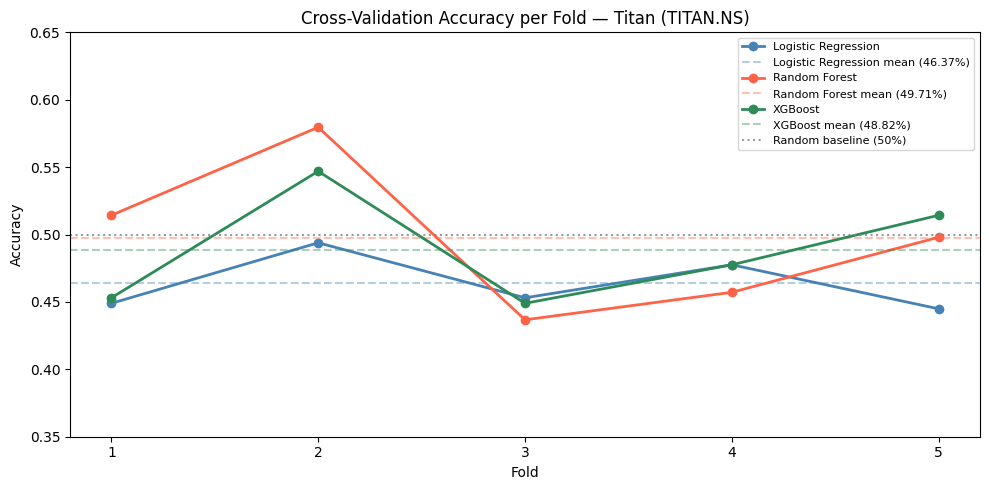

In [81]:
import matplotlib.pyplot as plt
import numpy as np

cv_results = {
    'Logistic Regression': np.array([r['accuracy'] for r in results['Logistic Regression']]),
    'Random Forest':       np.array([r['accuracy'] for r in results_rf['Random Forest']]),
    'XGBoost':             np.array([r['accuracy'] for r in results_xgb['XGBoost']])
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue', 'tomato', 'seagreen']

for i, (name, scores) in enumerate(cv_results.items()):
    ax.plot(range(1, 6), scores, marker='o', label=name, color=colors[i], linewidth=2)
    ax.axhline(scores.mean(), color=colors[i], linestyle='--', alpha=0.4,
               label=f'{name} mean ({scores.mean():.2%})')

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.8, linewidth=1.5,
           label='Random baseline (50%)')

ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Validation Accuracy per Fold — Titan (TITAN.NS)')
ax.set_xticks(range(1, 6))
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0.35, 0.65)

plt.tight_layout()
plt.savefig("plots/cv_accuracy_per_fold.png", dpi=300, bbox_inches="tight")
plt.show()

In [82]:
fold_labels = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    start_date = X.index[test_idx[0]].strftime('%b %Y')
    end_date   = X.index[test_idx[-1]].strftime('%b %Y')
    fold_labels.append(f"Fold {fold}\n{start_date}–{end_date}")

print(fold_labels)

['Fold 1\nMar 2021–Mar 2022', 'Fold 2\nMar 2022–Mar 2023', 'Fold 3\nMar 2023–Mar 2024', 'Fold 4\nMar 2024–Mar 2025', 'Fold 5\nMar 2025–Jun 2026']


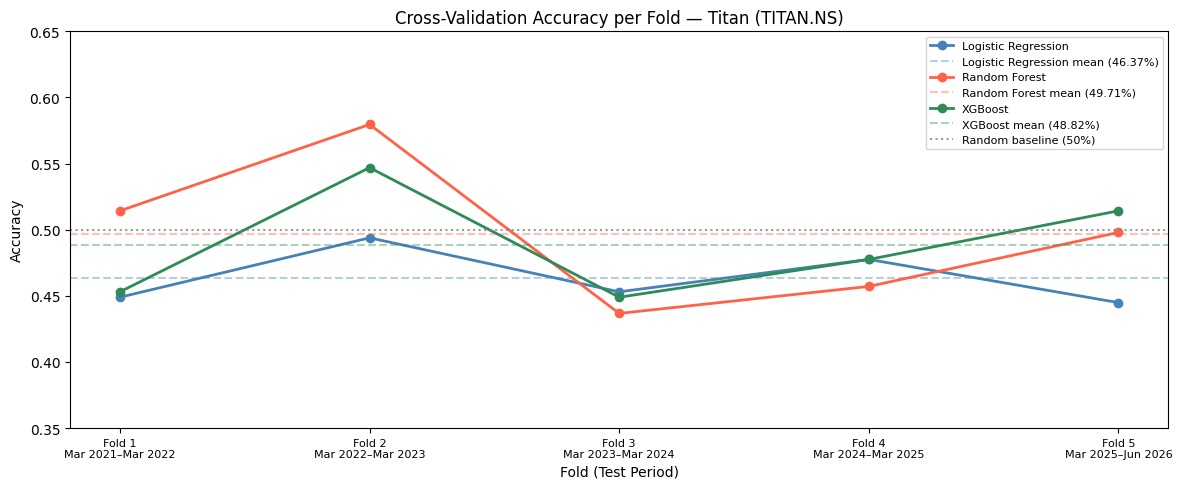

In [83]:
import matplotlib.pyplot as plt
import numpy as np

cv_results = {
    'Logistic Regression': np.array([r['accuracy'] for r in results['Logistic Regression']]),
    'Random Forest':       np.array([r['accuracy'] for r in results_rf['Random Forest']]),
    'XGBoost':             np.array([r['accuracy'] for r in results_xgb['XGBoost']])
}

fold_labels = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    start_date = X.index[test_idx[0]].strftime('%b %Y')
    end_date   = X.index[test_idx[-1]].strftime('%b %Y')
    fold_labels.append(f"Fold {fold}\n{start_date}–{end_date}")

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue', 'tomato', 'seagreen']

for i, (name, scores) in enumerate(cv_results.items()):
    ax.plot(range(1, 6), scores, marker='o', label=name,
            color=colors[i], linewidth=2)
    ax.axhline(scores.mean(), color=colors[i], linestyle='--', alpha=0.4,
               label=f'{name} mean ({scores.mean():.2%})')

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.8,
           linewidth=1.5, label='Random baseline (50%)')

ax.set_xlabel('Fold (Test Period)')
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Validation Accuracy per Fold — Titan (TITAN.NS)')
ax.set_xticks(range(1, 6))
ax.set_xticklabels(fold_labels, fontsize=8)
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0.35, 0.65)

plt.tight_layout()
plt.savefig("plots/cv_accuracy_per_fold.png", dpi=300, bbox_inches="tight")
plt.show()

Fold 1 — Train: 87.16% | Test: 45.31%
Fold 2 — Train: 85.44% | Test: 54.69%
Fold 3 — Train: 82.15% | Test: 44.90%
Fold 4 — Train: 81.07% | Test: 47.76%
Fold 5 — Train: 80.00% | Test: 51.43%


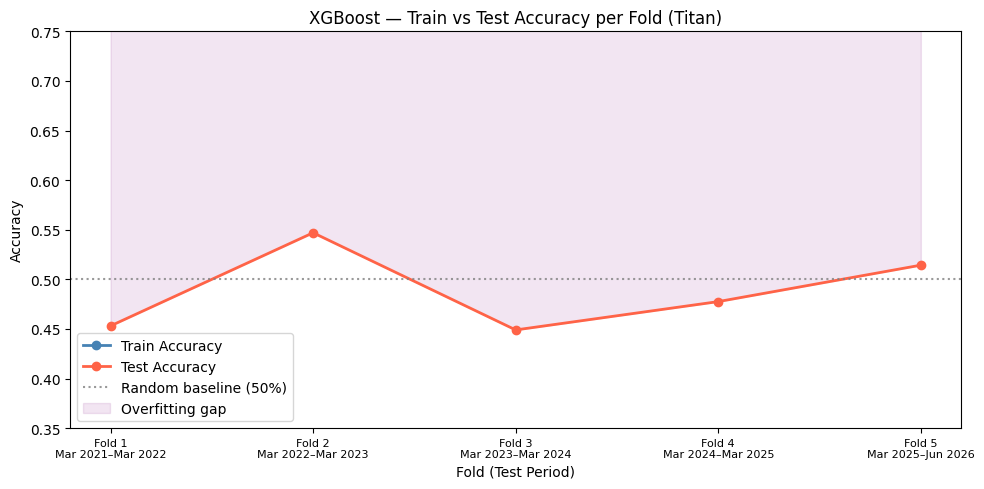

In [84]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif

xgb_train_acc = []
xgb_test_acc  = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    mi_scores    = mutual_info_classif(X_train, y_train, random_state=42)
    importance   = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    top_features = importance.head(15).index.tolist()

    X_train_filtered = X_train[top_features]
    X_test_filtered  = X_test[top_features]

    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        random_state=42,
        eval_metric='logloss'
    )
    xgb.fit(X_train_filtered, y_train)

    train_acc = accuracy_score(y_train, xgb.predict(X_train_filtered))
    test_acc  = accuracy_score(y_test,  xgb.predict(X_test_filtered))

    xgb_train_acc.append(train_acc)
    xgb_test_acc.append(test_acc)

    print(f"Fold {fold} — Train: {train_acc:.2%} | Test: {test_acc:.2%}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, 6), xgb_train_acc, marker='o', color='steelblue',
        linewidth=2, label='Train Accuracy')
ax.plot(range(1, 6), xgb_test_acc,  marker='o', color='tomato',
        linewidth=2, label='Test Accuracy')

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.8,
           linewidth=1.5, label='Random baseline (50%)')

ax.fill_between(range(1, 6), xgb_train_acc, xgb_test_acc,
                alpha=0.1, color='purple', label='Overfitting gap')

ax.set_xlabel('Fold (Test Period)')
ax.set_ylabel('Accuracy')
ax.set_title('XGBoost — Train vs Test Accuracy per Fold (Titan)')
ax.set_xticks(range(1, 6))
ax.set_xticklabels(fold_labels, fontsize=8)
ax.legend()
ax.set_ylim(0.35, 0.75)

plt.tight_layout()
plt.savefig("plots/xgb_train_vs_test.png", dpi=300, bbox_inches="tight")
plt.show()

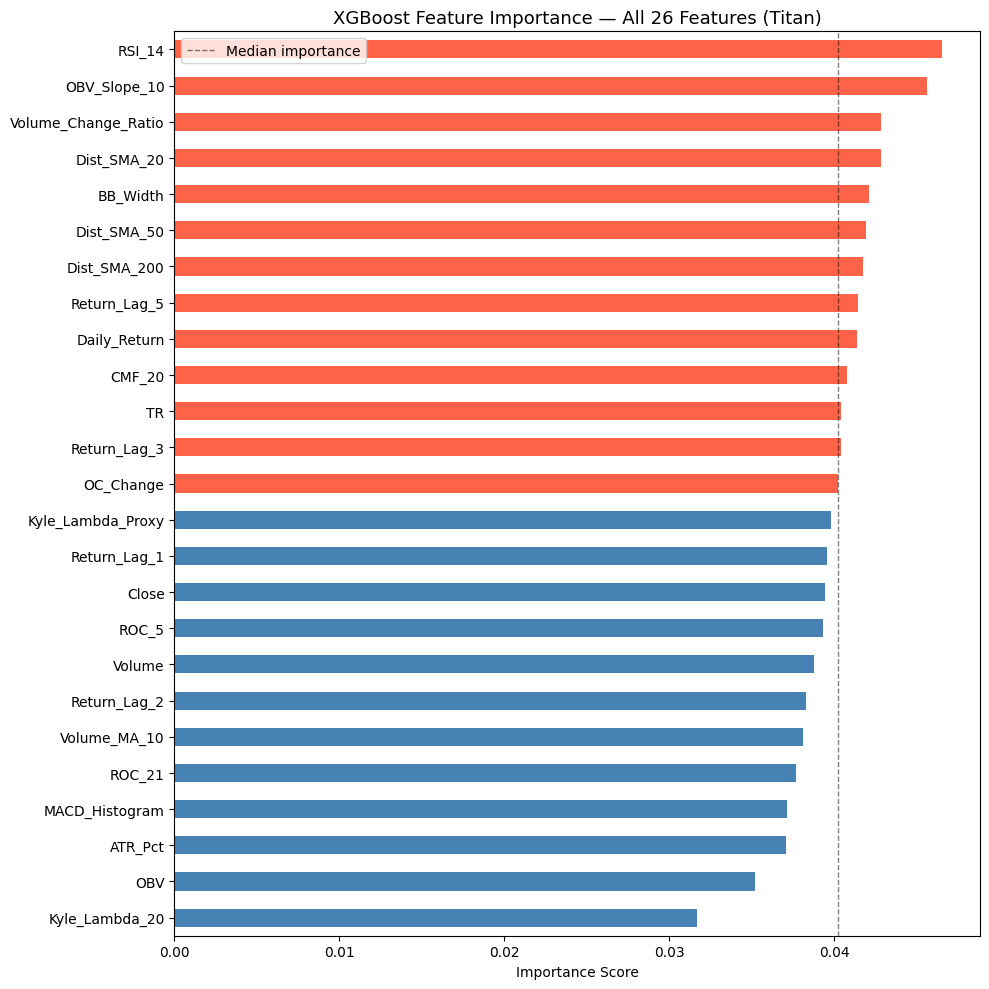


Feature Importance Ranking:
 1. RSI_14                    0.0465
 2. OBV_Slope_10              0.0456
 3. Volume_Change_Ratio       0.0428
 4. Dist_SMA_20               0.0428
 5. BB_Width                  0.0421
 6. Dist_SMA_50               0.0419
 7. Dist_SMA_200              0.0417
 8. Return_Lag_5              0.0414
 9. Daily_Return              0.0414
10. CMF_20                    0.0408
11. TR                        0.0404
12. Return_Lag_3              0.0404
13. OC_Change                 0.0402
14. Kyle_Lambda_Proxy         0.0398
15. Return_Lag_1              0.0395
16. Close                     0.0394
17. ROC_5                     0.0393
18. Volume                    0.0387
19. Return_Lag_2              0.0383
20. Volume_MA_10              0.0381
21. ROC_21                    0.0377
22. MACD_Histogram            0.0371
23. ATR_Pct                   0.0371
24. OBV                       0.0352
25. Kyle_Lambda_20            0.0317


In [85]:
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Train XGBoost on full training data (no fold, no MI filter — all 26 features)
split = int(len(X) * 0.8)
X_train_full = X.iloc[:split]
y_train_full = y.iloc[:split]

xgb_full = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    eval_metric='logloss'
)
xgb_full.fit(X_train_full, y_train_full)

# Feature importance
importance = pd.Series(
    xgb_full.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

colors = ['tomato' if v >= importance.median() else 'steelblue'
          for v in importance]

importance.plot(kind='barh', ax=ax, color=colors)

ax.axvline(importance.median(), color='black', linestyle='--',
           linewidth=1, alpha=0.5, label='Median importance')

ax.set_title('XGBoost Feature Importance — All 26 Features (Titan)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.legend()

plt.tight_layout()
plt.savefig("plots/xgb_feature_importance_all.png", dpi=300, bbox_inches="tight")
plt.show()

# Print ranked table
print("\nFeature Importance Ranking:")
print("="*40)
importance_desc = importance.sort_values(ascending=False)
for i, (feat, val) in enumerate(importance_desc.items(), 1):
    print(f"{i:2}. {feat:<25} {val:.4f}")

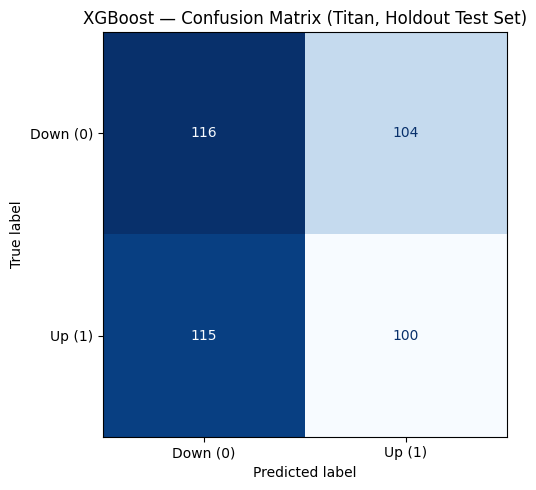

              precision    recall  f1-score   support

    Down (0)       0.50      0.53      0.51       220
      Up (1)       0.49      0.47      0.48       215

    accuracy                           0.50       435
   macro avg       0.50      0.50      0.50       435
weighted avg       0.50      0.50      0.50       435



In [86]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train on 80% , test on last 20%
split = int(len(X) * 0.8)
X_train_full = X.iloc[:split]
X_test_full  = X.iloc[split:]
y_train_full = y.iloc[:split]
y_test_full  = y.iloc[split:]

xgb_cm = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42,
    eval_metric='logloss'
)
xgb_cm.fit(X_train_full, y_train_full)
y_pred_cm = xgb_cm.predict(X_test_full)

# Confusion matrix
cm = confusion_matrix(y_test_full, y_pred_cm)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Down (0)', 'Up (1)']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title('XGBoost — Confusion Matrix (Titan, Holdout Test Set)', fontsize=12)

plt.tight_layout()
plt.savefig("plots/xgb_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Print metrics
from sklearn.metrics import classification_report
print(classification_report(y_test_full, y_pred_cm,
      target_names=['Down (0)', 'Up (1)']))

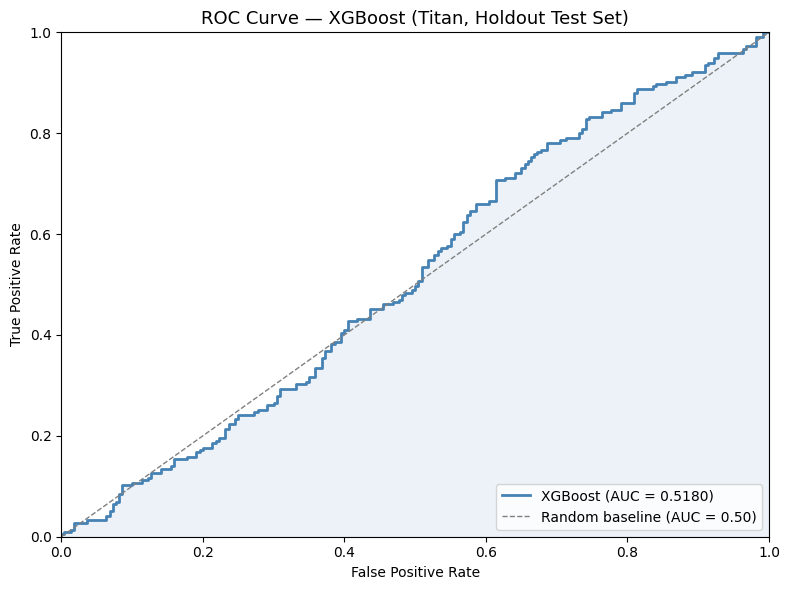

AUC Score: 0.5180


In [87]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities (not just 0/1)
y_proba = xgb_cm.predict_proba(X_test_full)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test_full, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'XGBoost (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1, label='Random baseline (AUC = 0.50)')

ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — XGBoost (Titan, Holdout Test Set)', fontsize=13)
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig("plots/xgb_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

 Threshold  Accuracy  Precision   Recall       F1      AUC
       0.0  0.494253        NaN      NaN      NaN      NaN
       0.1  0.494253        NaN      NaN      NaN      NaN
       0.2  0.494253   0.494145 0.981395 0.657321 0.499789
       0.3  0.505747   0.500000 0.934884 0.651540 0.510624
       0.4  0.540230   0.523810 0.767442 0.622642 0.542812
       0.5  0.496552   0.490196 0.465116 0.477327 0.496195
       0.6  0.489655   0.455696 0.167442 0.244898 0.485994
       0.7  0.505747   0.500000 0.027907 0.052863 0.500317
       0.8  0.505747        NaN      NaN      NaN      NaN
       0.9  0.505747        NaN      NaN      NaN      NaN
       1.0  0.505747        NaN      NaN      NaN      NaN


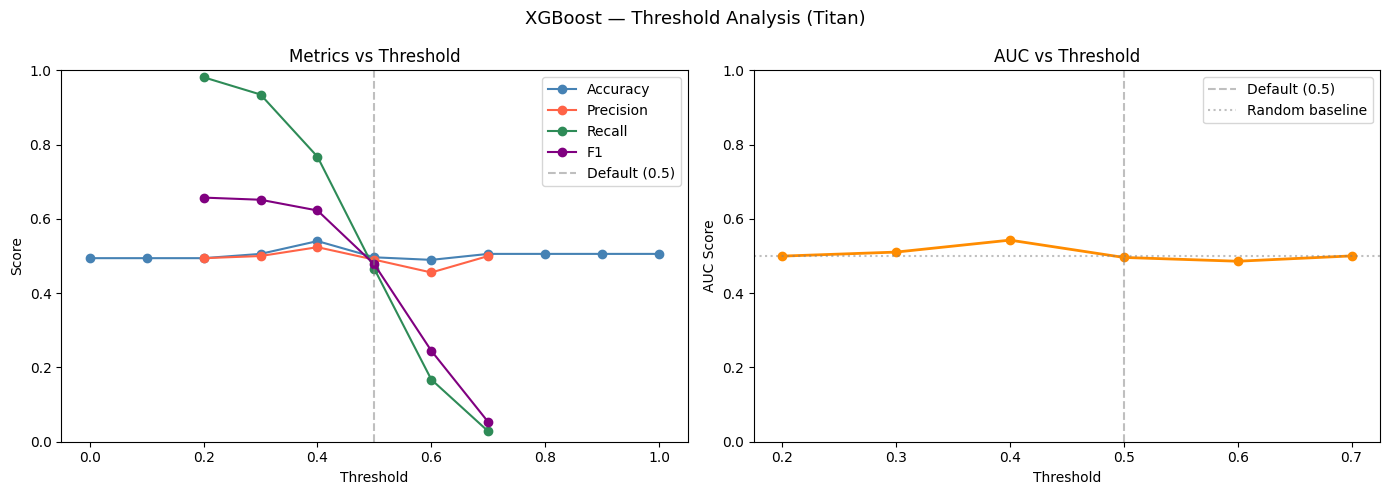

In [88]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

y_proba = xgb_cm.predict_proba(X_test_full)[:, 1]

thresholds = np.arange(0.0, 1.1, 0.1)

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    
    # skip if all predictions are same class
    if len(np.unique(y_pred_t)) < 2:
        rows.append({
            'Threshold': round(t, 1),
            'Accuracy':  accuracy_score(y_test_full, y_pred_t),
            'Precision': None,
            'Recall':    None,
            'F1':        None,
            'AUC':       None
        })
        continue

    rows.append({
        'Threshold': round(t, 1),
        'Accuracy':  accuracy_score(y_test_full, y_pred_t),
        'Precision': precision_score(y_test_full, y_pred_t, zero_division=0),
        'Recall':    recall_score(y_test_full, y_pred_t, zero_division=0),
        'F1':        f1_score(y_test_full, y_pred_t, zero_division=0),
        'AUC':       roc_auc_score(y_test_full, y_pred_t)
    })

df_thresh = pd.DataFrame(rows)
print(df_thresh.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — Accuracy, Precision, Recall, F1 vs Threshold
axes[0].plot(df_thresh['Threshold'], df_thresh['Accuracy'],
             marker='o', label='Accuracy', color='steelblue')
axes[0].plot(df_thresh['Threshold'], df_thresh['Precision'],
             marker='o', label='Precision', color='tomato')
axes[0].plot(df_thresh['Threshold'], df_thresh['Recall'],
             marker='o', label='Recall', color='seagreen')
axes[0].plot(df_thresh['Threshold'], df_thresh['F1'],
             marker='o', label='F1', color='purple')
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Threshold')
axes[0].legend()
axes[0].set_ylim(0, 1)

# Right — AUC vs Threshold
axes[1].plot(df_thresh['Threshold'], df_thresh['AUC'],
             marker='o', color='darkorange', linewidth=2)
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Random baseline')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('AUC Score')
axes[1].set_title('AUC vs Threshold')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.suptitle('XGBoost — Threshold Analysis (Titan)', fontsize=13)
plt.tight_layout()
plt.savefig("plots/xgb_threshold_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

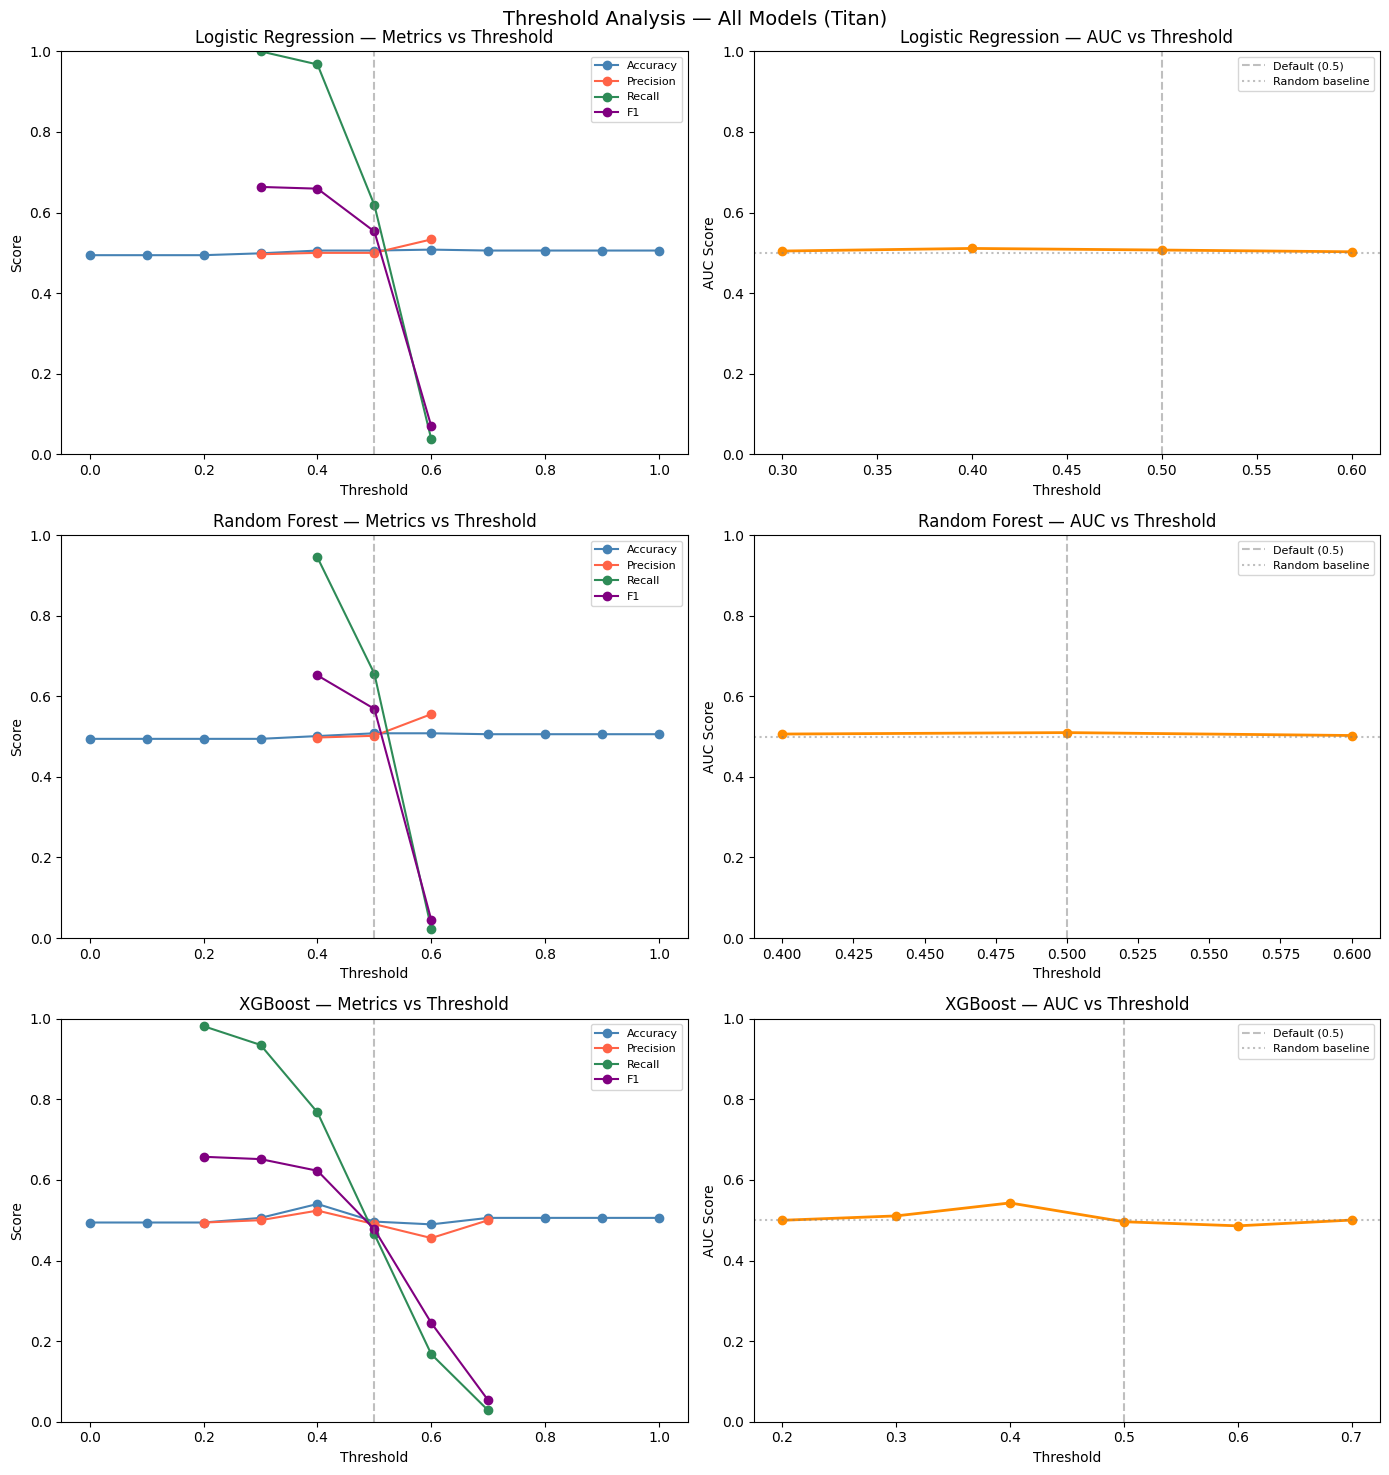

In [89]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Train all 3 models on same 80/20 split ──────────────────────────────────
split = int(len(X) * 0.8)
X_train_full = X.iloc[:split]
X_test_full  = X.iloc[split:]
y_train_full = y.iloc[:split]
y_test_full  = y.iloc[split:]

# Logistic Regression (needs scaling)
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train_full)
X_test_sc    = scaler.transform(X_test_full)
lr_full      = LogisticRegression(max_iter=1000, random_state=42)
lr_full.fit(X_train_sc, y_train_full)
y_proba_lr   = lr_full.predict_proba(X_test_sc)[:, 1]

# Random Forest
rf_full      = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    min_samples_leaf=10, random_state=42, n_jobs=-1
)
rf_full.fit(X_train_full, y_train_full)
y_proba_rf   = rf_full.predict_proba(X_test_full)[:, 1]

# XGBoost — already trained as xgb_cm, just reuse probabilities
y_proba_xgb  = xgb_cm.predict_proba(X_test_full)[:, 1]

# ── Threshold analysis function ──────────────────────────────────────────────
def threshold_analysis(y_true, y_proba):
    rows = []
    for t in np.arange(0.0, 1.1, 0.1):
        y_pred_t = (y_proba >= t).astype(int)
        if len(np.unique(y_pred_t)) < 2:
            rows.append({
                'Threshold': round(t, 1),
                'Accuracy':  accuracy_score(y_true, y_pred_t),
                'Precision': None, 'Recall': None,
                'F1': None, 'AUC': None
            })
            continue
        rows.append({
            'Threshold': round(t, 1),
            'Accuracy':  accuracy_score(y_true, y_pred_t),
            'Precision': precision_score(y_true, y_pred_t, zero_division=0),
            'Recall':    recall_score(y_true, y_pred_t, zero_division=0),
            'F1':        f1_score(y_true, y_pred_t, zero_division=0),
            'AUC':       roc_auc_score(y_true, y_pred_t)
        })
    return pd.DataFrame(rows)

df_lr  = threshold_analysis(y_test_full, y_proba_lr)
df_rf  = threshold_analysis(y_test_full, y_proba_rf)
df_xgb = threshold_analysis(y_test_full, y_proba_xgb)

# ── Plot all 3 models ────────────────────────────────────────────────────────
models = {
    'Logistic Regression': df_lr,
    'Random Forest':       df_rf,
    'XGBoost':             df_xgb
}

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for row, (name, df_t) in enumerate(models.items()):
    # Left — metrics vs threshold
    axes[row, 0].plot(df_t['Threshold'], df_t['Accuracy'],
                      marker='o', label='Accuracy',  color='steelblue')
    axes[row, 0].plot(df_t['Threshold'], df_t['Precision'],
                      marker='o', label='Precision', color='tomato')
    axes[row, 0].plot(df_t['Threshold'], df_t['Recall'],
                      marker='o', label='Recall',    color='seagreen')
    axes[row, 0].plot(df_t['Threshold'], df_t['F1'],
                      marker='o', label='F1',        color='purple')
    axes[row, 0].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[row, 0].set_title(f'{name} — Metrics vs Threshold')
    axes[row, 0].set_xlabel('Threshold')
    axes[row, 0].set_ylabel('Score')
    axes[row, 0].legend(fontsize=8)
    axes[row, 0].set_ylim(0, 1)

    # Right — AUC vs threshold
    axes[row, 1].plot(df_t['Threshold'], df_t['AUC'],
                      marker='o', color='darkorange', linewidth=2)
    axes[row, 1].axvline(0.5, color='gray', linestyle='--',
                         alpha=0.5, label='Default (0.5)')
    axes[row, 1].axhline(0.5, color='gray', linestyle=':',
                         alpha=0.5, label='Random baseline')
    axes[row, 1].set_title(f'{name} — AUC vs Threshold')
    axes[row, 1].set_xlabel('Threshold')
    axes[row, 1].set_ylabel('AUC Score')
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].set_ylim(0, 1)

plt.suptitle('Threshold Analysis — All Models (Titan)', fontsize=14)
plt.tight_layout()
plt.savefig("plots/all_models_threshold_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [90]:
print(df.columns)

Index(['Close', 'Volume', 'OC_Change', 'Daily_Return', 'RSI_14',
       'MACD_Histogram', 'ROC_5', 'ROC_21', 'Dist_SMA_20', 'Dist_SMA_50',
       'Dist_SMA_200', 'BB_Width', 'TR', 'Volume_MA_10', 'Volume_Change_Ratio',
       'CMF_20', 'OBV', 'OBV_Slope_10', 'Return_Lag_1', 'Return_Lag_2',
       'Return_Lag_3', 'Return_Lag_5', 'Kyle_Lambda_Proxy', 'Kyle_Lambda_20',
       'Target', 'ATR_Pct'],
      dtype='object')


In [91]:
len(df.columns)

26

In [92]:
feature_table = pd.DataFrame({
    "S. No.": range(1, len(df.columns) + 1),
    "Feature": df.columns
})

print(feature_table.to_string(index=False))

 S. No.             Feature
      1               Close
      2              Volume
      3           OC_Change
      4        Daily_Return
      5              RSI_14
      6      MACD_Histogram
      7               ROC_5
      8              ROC_21
      9         Dist_SMA_20
     10         Dist_SMA_50
     11        Dist_SMA_200
     12            BB_Width
     13                  TR
     14        Volume_MA_10
     15 Volume_Change_Ratio
     16              CMF_20
     17                 OBV
     18        OBV_Slope_10
     19        Return_Lag_1
     20        Return_Lag_2
     21        Return_Lag_3
     22        Return_Lag_5
     23   Kyle_Lambda_Proxy
     24      Kyle_Lambda_20
     25              Target
     26             ATR_Pct


In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

for name, obj in list(globals().items()):
    if isinstance(obj, LogisticRegression):
        print("Logistic Regression:", name)

for name, obj in list(globals().items()):
    if isinstance(obj, RandomForestClassifier):
        print("Random Forest:", name)

for name, obj in list(globals().items()):
    if isinstance(obj, XGBClassifier):
        print("XGBoost:", name)

Logistic Regression: lr
Logistic Regression: lr_full
Random Forest: rf
Random Forest: rf_full
XGBoost: xgb
XGBoost: xgb_full
XGBoost: xgb_cm


In [94]:
print(xgb_full is xgb_cm)

False


In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

models = {
    "Logistic Regression": lr_full,
    "Random Forest": rf_full,
    "XGBoost": xgb_full
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)

comparison_df

C:\Users\parth\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\parth\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Random Forest,0.506122,0.503650,0.565574,0.532819,0.518659
0,Logistic Regression,0.497959,0.497959,1.000000,0.664850,0.500000
2,XGBoost,0.497959,0.495238,0.426230,0.458150,0.530255


In [96]:
import joblib

joblib.dump(lr_full, "../models/logistic_regression.pkl")
joblib.dump(rf_full, "../models/random_forest.pkl")
joblib.dump(xgb_cm, "../models/xgboost.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Models saved successfully!")

Models saved successfully!


In [97]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
